<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>Aprendizaje de Máquina</b>
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">APRENDIZAJE SUPERVISADO</strong>
</div>

# **CLASIFICACIÓN**

## Regresión Logística

La regresión logística es un modelo estadístico utilizado para **clasificación binaria**, que estima la probabilidad de que una instancia pertenezca a una clase.

$$
P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b), \quad \text{donde } \sigma(z) = \frac{1}{1 + e^{-z}}
$$

- Salida: probabilidad en el rango $[0, 1]$
- Frontera de decisión: $\mathbf{w}^\top \mathbf{x} + b = 0$
- Utiliza la función **sigmoide** para convertir la salida lineal en probabilidad

> Ideal para problemas de clasificación como: spam vs. no spam, enfermedad sí/no, etc.



Ecuación de la frontera de decisión: 2.215·x₁ + -0.151·x₂ + 0.143 = 0

Punto resaltado: x = [-1.31250291  1.0140342 ], Probabilidad estimada de clase 1 = 0.051





C:\Users\Flavio\AppData\Local\Temp\ipykernel_25324\411380007.py:64: UserWarning: You passed a edgecolor/edgecolors ('gray') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,


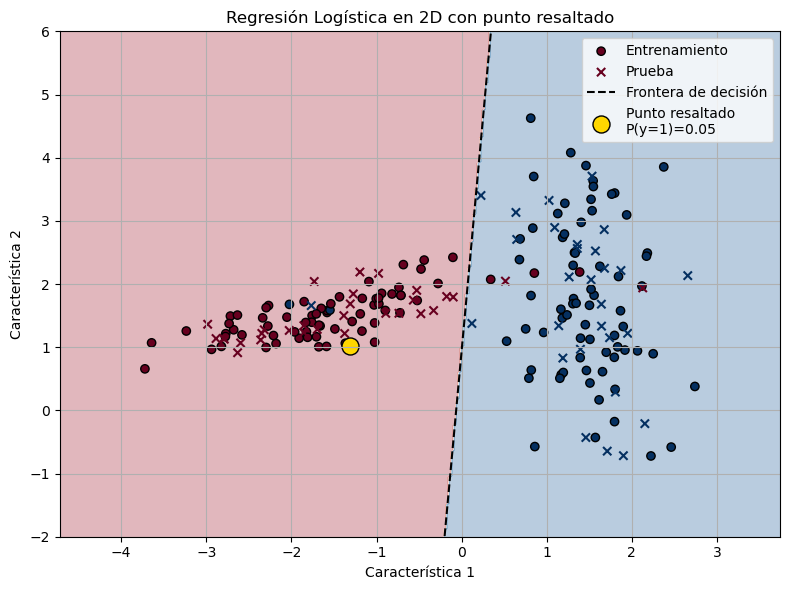

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

#===========================================================
# Generar datos bidimensionales (2 características)
X, y = make_classification(n_samples=200, n_features=2, 
                           n_informative=2, n_redundant=0, 
                           n_clusters_per_class=1, flip_y=0.05,
                           class_sep=1.5, random_state=0)

#===========================================================
#===========================================================
# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

#===========================================================
# Entrenar modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

#===========================================================
# Obtener coeficientes y mostrar ecuación de la frontera
w = model.coef_[0]
b = model.intercept_[0]
print(f"\n\nEcuación de la frontera de decisión: {w[0]:.3f}·x₁ + {w[1]:.3f}·x₂ + {b:.3f} = 0")


#===========================================================
# Seleccionar un punto de prueba y calcular su probabilidad
idx = np.random.randint(len(X_test))
point = X_test[idx].reshape(1, -1)
prob = model.predict_proba(point)[0, 1]
print(f"\nPunto resaltado: x = {point[0]}, Probabilidad estimada de clase 1 = {prob:.3f}")
print("\n\n")

#===========================================================
# Graficar datos y frontera de decisión
plt.figure(figsize=(8, 6))

# Malla para el fondo
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = -2, 6  # Ajuste de los límites del eje y
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

#===========================================================
# Predicción sobre cada punto de la malla
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#===========================================================
# Dibujar región de decisión
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

#===========================================================
# Dibujar puntos reales
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
            cmap=plt.cm.RdBu, edgecolors='k', label='Entrenamiento')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, 
            cmap=plt.cm.RdBu, edgecolors='gray', marker='x', label='Prueba')

#===========================================================
# Dibujar la frontera de decisión (línea)
x_vals = np.linspace(x_min, x_max, 300)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, color='black', linestyle='--', label='Frontera de decisión')

#===========================================================
# Dibujar punto resaltado
plt.scatter(point[0, 0], point[0, 1], color='gold', edgecolor='black',
            s=150, marker='o', label=f'Punto resaltado\nP(y=1)={prob:.2f}')

#===========================================================
# Configurar gráfico
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.ylim(-2, 6)  # Establecer el eje Y de -2 a 6
plt.title('Regresión Logística en 2D con punto resaltado')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


## **Máquinas de Vectores de Soporte (SVM)**

Las Máquinas de Vectores de Soporte (SVM, por sus siglas en inglés) son algoritmos de clasificación supervisada que buscan encontrar el **hiperplano óptimo** que separa dos clases con el **mayor margen posible**.

- **Margen**: distancia entre el hiperplano y los puntos más cercanos de cada clase. 
- **Vectores de soporte**: son los puntos de entrenamiento que se encuentran sobre los márgenes; definen completamente el hiperplano de separación.
- **Hiperplano de decisión**: tiene la forma $w^T x + b = 0$ y separa las clases.
- En el caso de SVM **lineal**, la separación se hace mediante una línea recta (en 2D) o un hiperplano (en dimensiones mayores).
- SVM también puede extenderse a casos **no lineales** usando **kernels** (por ejemplo, RBF, polinomial).

### Función objetivo (SVM con margen duro):

$$
\min_{w, b} \ \frac{1}{2} \|w\|^2 \quad \text{sujeto a } \quad y_i (w^T x_i + b) \geq 1 \quad \forall i
$$

- Esta formulación busca **maximizar el margen** (minimizando la norma de $w$) bajo la restricción de que todos los puntos estén **fuera o sobre la margen** (es decir, correctamente clasificados y con un margen mínimo de 1).

**Ventajas:**
- Eficiente en espacios de alta dimensión.
- Robusto frente a sobreajuste si se elige bien el parámetro `C` en la versión suave (*soft-margin SVM*).

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


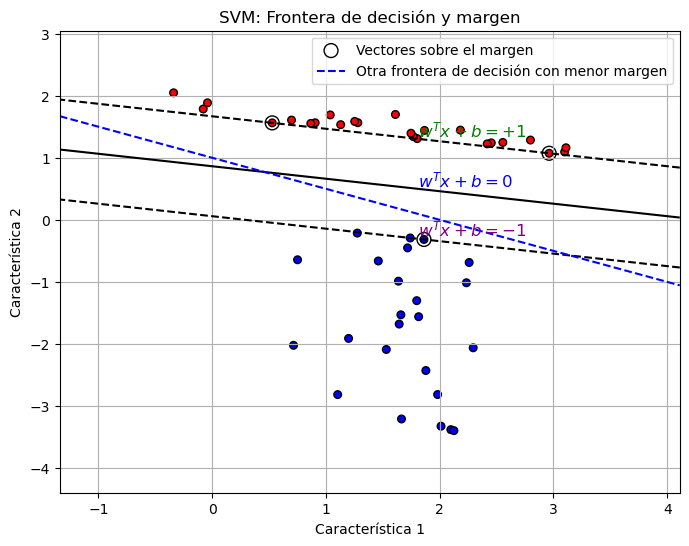

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification


#=========================================================================
# Generar datos de dos clases en 2D (al menos 20 puntos por clase)
X, y = make_classification(n_samples=50, n_features=2, 
                           n_informative=2, n_redundant=0, 
                           n_clusters_per_class=1, class_sep=1.5,
                           random_state=42)


#=========================================================================
#  Entrenar SVM lineal con margen suave
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X, y)


#=========================================================================
#  Extraer coeficientes
w = clf.coef_[0]
b = clf.intercept_[0]


#=========================================================================
#  Calcular margen
margin = 1 / np.linalg.norm(w)


#=========================================================================
#  Crear malla para graficar frontera de decisión
xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500)
yy = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)


#=========================================================================
#  Obtener todos los vectores de soporte
support_vectors = clf.support_vectors_


#=========================================================================
#  Filtrar solo los vectores de soporte exactamente en el margen (±1)
decision_values = clf.decision_function(support_vectors)
epsilon = 1e-3  # tolerancia
on_margin_mask = np.isclose(np.abs(decision_values), 1.0, atol=epsilon)
margin_support_vectors = support_vectors[on_margin_mask]



#=========================================================================
#  Graficar
plt.figure(figsize=(8, 6))


# --- Eliminar los puntos que están dentro del margen pero son vectores de soporte ---
# Índices de todos los vectores de soporte
all_sv_indices = clf.support_

# Índices de los vectores de soporte sobre el margen
margin_sv_indices = all_sv_indices[on_margin_mask]

# Crear una máscara booleana para todos los puntos
mask = np.ones(len(X), dtype=bool)
mask[all_sv_indices] = False  # eliminar todos los vectores de soporte
mask[margin_sv_indices] = True  # conservar solo los que están sobre el margen

# Graficar puntos (excluyendo los SV internos al margen)
plt.scatter(X[mask, 0], X[mask, 1], c=y[mask], cmap='bwr', s=30, edgecolors='k')


## Graficar todos los puntos
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30, edgecolors='k')

# Frontera de decisión y márgenes
plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
            linestyles=['--', '-', '--'])

# Añadir etiquetas con las ecuaciones de las márgenes y la frontera
x_pos = X[:, 0].mean()

# Línea +1 (margen positivo)
y_plus = (-w[0]*x_pos - b + 1)/w[1]
plt.text(x_pos + 0.2, y_plus, r'$w^T x + b = +1$', fontsize=12, color='green')

# Línea -1 (margen negativo)
y_minus = (-w[0]*x_pos - b - 1)/w[1]
plt.text(x_pos + 0.2, y_minus, r'$w^T x + b = -1$', fontsize=12, color='purple')

# Línea de decisión
y_zero = (-w[0]*x_pos - b)/w[1]
plt.text(x_pos + 0.2, y_zero, r'$w^T x + b = 0$', fontsize=12, color='blue')

# Graficar solo los vectores de soporte que están exactamente en el margen
plt.scatter(margin_support_vectors[:, 0], margin_support_vectors[:, 1],
            s=100, facecolors='none', edgecolors='k', label='Vectores sobre el margen')

# Otra frontera de decisión con menor margen (ejemplo: pendiente distinta)
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
plt.plot(x_vals, -0.5 * x_vals + 1, 'b--', label='Otra frontera de decisión con menor margen')

plt.title("SVM: Frontera de decisión y margen")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.grid(True)
plt.axis('tight')
plt.show()


### Efecto del hiperparámetro $C$ en el modelo SVM

Cuando se entrena una Máquina de Vectores de Soporte (SVM), el hiperparámetro $C$ controla el equilibrio entre un margen amplio y el número de errores de clasificación:

- **Cuando $C$ es grande**:
  - El modelo penaliza fuertemente los errores de clasificación.
  - Tiende a encontrar un margen más estrecho para que todos los puntos estén bien clasificados.
  - Solo unos pocos vectores de soporte, ubicados justo en las márgenes, determinan la frontera.
  - El modelo se ajusta mucho a los datos de entrenamiento y puede sobreajustar si hay ruido.

- **Cuando $C$ es pequeño**:
  - El modelo permite errores de clasificación más fácilmente.
  - El margen se amplía, incluso si algunos puntos están mal clasificados.
  - Muchos vectores de soporte pueden estar dentro del margen o incluso en el lado incorrecto de la frontera.
  - El clasificador busca una mejor generalización aceptando que algunos puntos estén mal clasificados.

### ¿Cómo se definen las márgenes y la frontera en este caso?

Incluso cuando hay muchos vectores de soporte (por un $C$ pequeño), la **frontera de decisión** sigue definiéndose como la recta (o superficie en alta dimensión) que satisface:

$$
w^T x + b = 0
$$

Las **márgenes** están dadas por las rectas:

$$
w^T x + b = \pm 1
$$

Sin embargo, con $C$ pequeño, muchos vectores de soporte **violan** estas condiciones (es decir, están **dentro del margen** o incluso **clasificados incorrectamente**). Estas violaciones se controlan con **variables de holgura** $\xi_i$, lo que significa que el modelo minimiza la siguiente función:

$$
\frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i
$$

donde:

- $\|w\|^2$ controla el ancho del margen (más pequeño implica márgenes más anchos).
- $\xi_i$ mide cuánto un punto viola el margen.

Por eso, al disminuir $C$, se acepta un mayor $\sum \xi_i$, lo que permite más puntos dentro del margen o mal clasificados, y por lo tanto **más vectores de soporte afectan la frontera**.

### Conclusión

- Un menor valor de $C$ hace que la SVM sea más tolerante a errores y ruidos, resultando en una frontera más suave con mayor número de vectores de soporte, muchos de ellos dentro del margen.
- Un mayor valor de $C$ impone una frontera más rígida y ajustada, con menos vectores de soporte estrictamente sobre las márgenes.


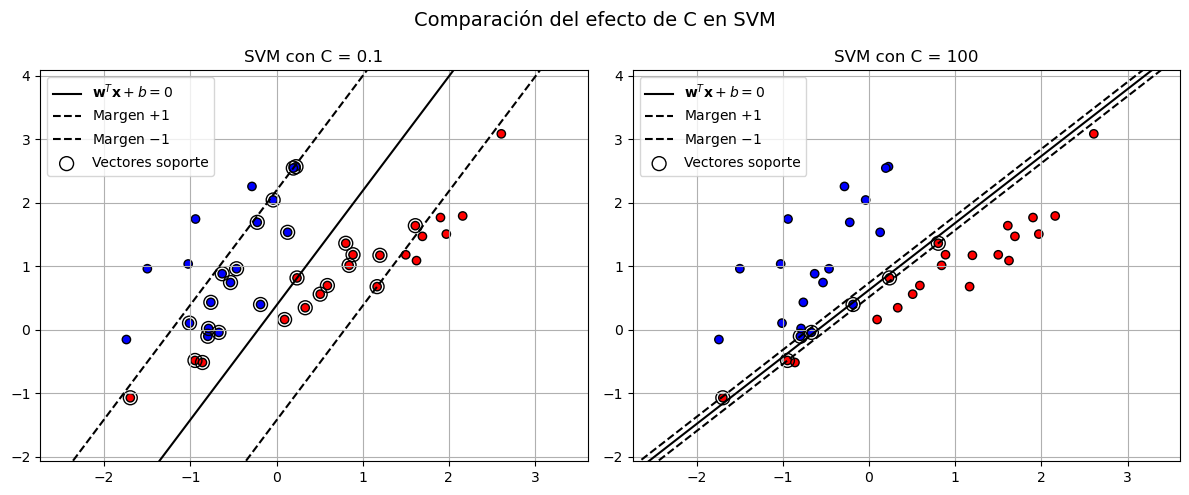

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification


##########################################################################
# Crear datos bidimensionales no linealmente separables perfectos
X, y = make_classification(n_samples=40, n_features=2, 
                           n_informative=2, n_redundant=0, 
                           n_clusters_per_class=1, class_sep=0.8, 
                           random_state=42)
y = 2 * y - 1  # Convertir etiquetas a -1 y 1


##########################################################################
# Ajustar dos clasificadores SVM con diferentes valores de C
Cs = [0.1, 100]  # C pequeño vs C grande

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, C in zip(axes, Cs):
    clf = svm.SVC(kernel='linear', C=C)
    clf.fit(X, y)

    # Obtener w y b para calcular márgenes
    w = clf.coef_[0]
    b = clf.intercept_[0]
    margin = 1 / np.linalg.norm(w)

    # Recta frontera: w^T x + b = 0
    xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500)
    yy = -(w[0] * xx + b) / w[1]

    # Márgenes: w^T x + b = ±1
    yy_margin1 = -(w[0] * xx + b - 1) / w[1]
    yy_margin2 = -(w[0] * xx + b + 1) / w[1]

    # Graficar puntos
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    
    # Dibujar frontera de decisión y márgenes
    ax.plot(xx, yy, 'k-', label=r'$\mathbf{w}^T\mathbf{x} + b = 0$')
    ax.plot(xx, yy_margin1, 'k--', label=r'Margen $+1$')
    ax.plot(xx, yy_margin2, 'k--', label=r'Margen $-1$')

    # Dibujar vectores de soporte
    ax.scatter(clf.support_vectors_[:, 0], 
               clf.support_vectors_[:, 1], 
               s=100, facecolors='none', edgecolors='k', label='Vectores soporte')

    ax.set_title(f"SVM con C = {C}")
    ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    ax.legend()
    ax.grid(True)

plt.suptitle("Comparación del efecto de C en SVM", fontsize=14)
plt.tight_layout()
plt.show()


### Problema No lineal con kernel RBF

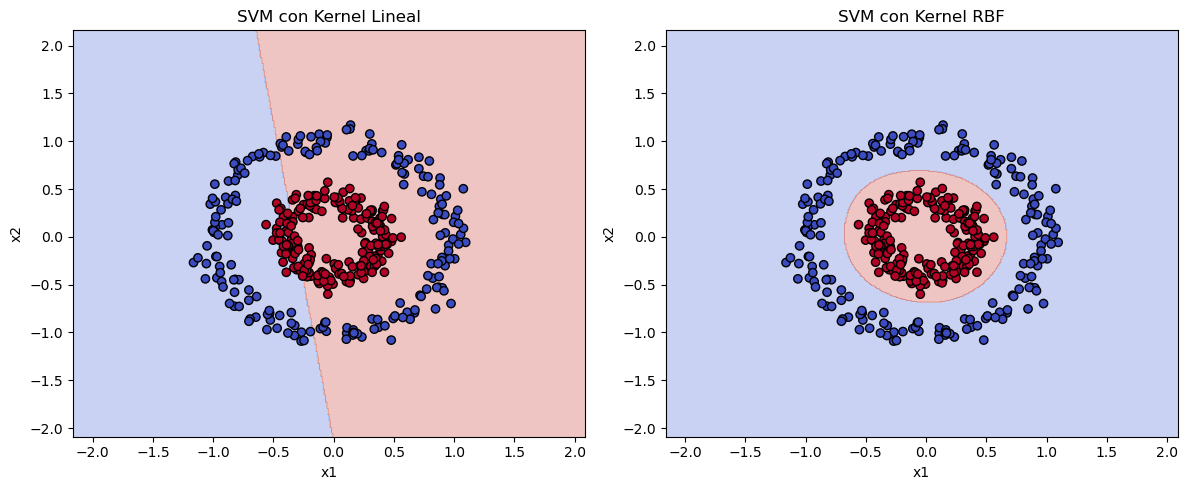

In [4]:
#========================================================================
# Ejemplo: SVM Lineal vs SVM con Kernel RBF
# Regiones de decisión coloreadas
#========================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

#---------------------------------------------------------
# 1. Generar datos no linealmente separables (dos círculos)
#---------------------------------------------------------

X, y = make_circles(n_samples=400, factor=0.4, noise=0.08, random_state=0)

#---------------------------------------------------------
# 2. Entrenar modelos
#---------------------------------------------------------

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X, y)

svm_rbf = SVC(kernel='rbf', gamma=2, C=1)
svm_rbf.fit(X, y)

#---------------------------------------------------------
# 3. Crear malla para regiones de decisión
#---------------------------------------------------------

h = 0.01

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid = np.c_[xx.ravel(), yy.ravel()]

Z_linear = svm_linear.predict(grid)
Z_linear = Z_linear.reshape(xx.shape)

Z_rbf = svm_rbf.predict(grid)
Z_rbf = Z_rbf.reshape(xx.shape)

#---------------------------------------------------------
# 4. Graficar
#---------------------------------------------------------

fig, ax = plt.subplots(1,2, figsize=(12,5))

#---------------------------
# SVM Lineal
#---------------------------

ax[0].contourf(xx, yy, Z_linear, alpha=0.3, cmap=plt.cm.coolwarm)
ax[0].scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[0].set_title("SVM con Kernel Lineal")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")

#---------------------------
# SVM RBF
#---------------------------

ax[1].contourf(xx, yy, Z_rbf, alpha=0.3, cmap=plt.cm.coolwarm)
ax[1].scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[1].set_title("SVM con Kernel RBF")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")

plt.tight_layout()
plt.show()

## Separación No Lineal con SVM y Núcleo RBF

Este experimento ilustra cómo las Máquinas de Vectores de Soporte (SVM) pueden resolver problemas de clasificación no lineal utilizando funciones *kernel*.

- Se utiliza el conjunto de datos `make_circles`, que genera puntos en forma de anillos concéntricos, lo que lo hace **no separable linealmente** en el espacio original.

- **Izquierda:** se entrena una SVM con **kernel lineal**, que intenta encontrar un hiperplano (una línea en 2D) que separe las clases. Dado que los datos no son linealmente separables, la clasificación resulta deficiente.

- **Derecha:** se entrena una SVM con **kernel RBF (Radial Basis Function)**, definido como  
  $$
  K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
  $$
  Este *kernel* permite proyectar los datos a un espacio de mayor dimensión donde **sí es posible separarlos linealmente**. El algoritmo encuentra entonces una frontera de decisión no lineal en el espacio original, que se adapta a la forma circular de los datos.

#### ¿Qué es un Kernel?

Un *kernel* es una función que calcula el producto interno entre imágenes de los datos en un espacio de características de alta (posiblemente infinita) dimensión, sin necesidad de realizar explícitamente dicha transformación. Esto se conoce como el **truco del kernel**.

Algunos *kernels* comunes:
- **Lineal**: $K(x_i, x_j) = x_i^T x_j$
- **Polinomial**: $K(x_i, x_j) = (\gamma x_i^T x_j + r)^d$
- **RBF (Gaussiano)**: $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$
- **Sigmoide**: $K(x_i, x_j) = \tanh(\kappa x_i^T x_j + \theta)$

Cada uno de estos *kernels* define una forma diferente de medir la similitud entre puntos y por tanto, permite encontrar diferentes tipos de fronteras de decisión.

Este ejemplo destaca cómo elegir un *kernel* adecuado puede hacer la diferencia entre una clasificación fallida y una clasificación exitosa.


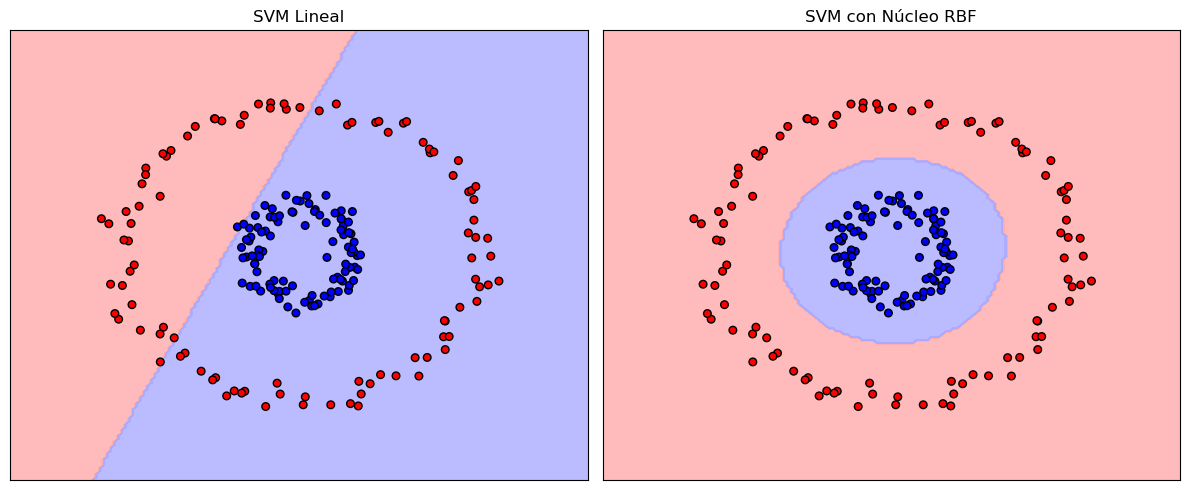

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles
from matplotlib.colors import ListedColormap

# 1. Generar datos no linealmente separables
X, y = make_circles(n_samples=200, factor=0.3, noise=0.05, random_state=0)

# 2. Definir dos clasificadores SVM
clf_linear = svm.SVC(kernel='linear', C=1.0)
clf_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale')

# 3. Entrenar los clasificadores
clf_linear.fit(X, y)
clf_rbf.fit(X, y)

# 4. Crear una malla para graficar las fronteras
h = .02  # paso de la malla
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 5. Predecir sobre la malla
Z_linear = clf_linear.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = clf_rbf.predict(np.c_[xx.ravel(), yy.ravel()])

Z_linear = Z_linear.reshape(xx.shape)
Z_rbf = Z_rbf.reshape(xx.shape)

# 6. Graficar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

titles = ['SVM Lineal', 'SVM con Núcleo RBF']
models = [Z_linear, Z_rbf]

for ax, Z, title in zip(axes, models, titles):
    ax.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']), s=30, edgecolors='k')
    ax.set_title(title)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())

plt.tight_layout()
plt.show()


## KNN

### Clasificación con **k-Vecinos más Cercanos (k-NN)**

La técnica de **k-Nearest Neighbors (k-NN)** es un método de clasificación supervisada que asigna la clase de un nuevo punto basándose en las clases de sus vecinos más cercanos en el espacio de características.

#### Principio del algoritmo
Dado un punto a clasificar:
- Se calcula la distancia (usualmente Euclidiana) a todos los puntos del conjunto de entrenamiento.
- Se seleccionan los \( k \) vecinos más cercanos.
- Se asigna la clase mayoritaria entre esos vecinos.

#### Elección del parámetro \( k \)
El valor de \( k \) es un **hiperparámetro** clave que influye directamente en el rendimiento del modelo:

- **Valores pequeños de \( k \) (por ejemplo, \( k=1 \))**:
  - El modelo es muy flexible.
  - Se adapta mucho al ruido (puede memorizar).
  - Riesgo de **sobreajuste** (overfitting).

- **Valores grandes de \( k \)**:
  - El modelo se vuelve más estable.
  - Las fronteras de decisión se suavizan.
  - Riesgo de **subajuste** (underfitting), especialmente si las clases no son fácilmente separables.

#### Ejemplo visual
A continuación se presentan gráficos que muestran el efecto de distintos valores de \( k \) sobre un conjunto de datos no linealmente separable. Se puede observar cómo la forma de las regiones de decisión cambia conforme se ajusta este parámetro.


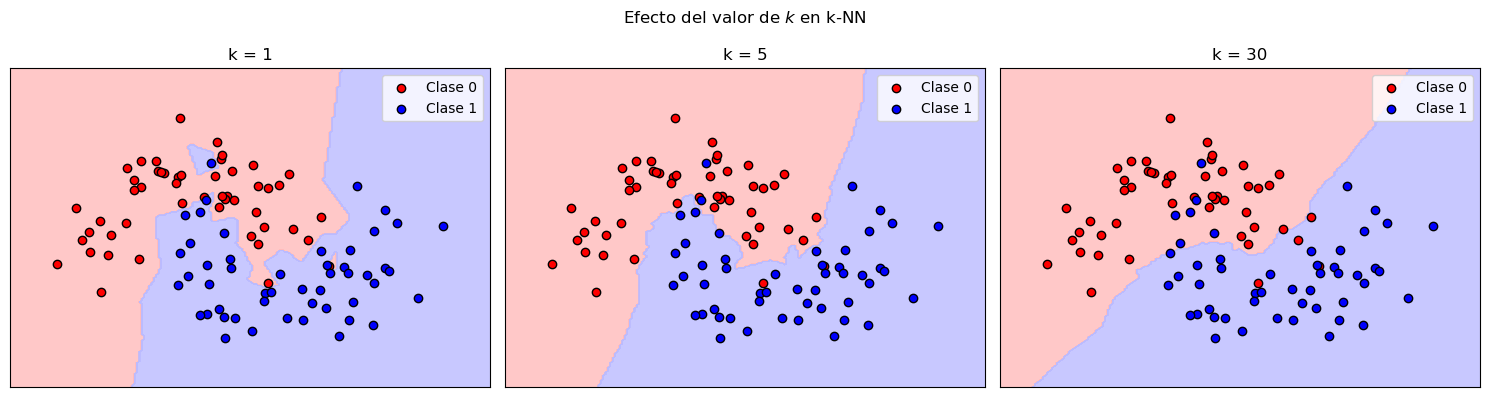

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap


#========================================================================
# Crear conjunto de datos no linealmente separable
X, y = make_moons(n_samples=100, noise=0.25, random_state=42)


#========================================================================
# Crear función para graficar regiones de decisión
def plot_knn_decision_boundary(k_values, X, y):
    cmap_light = ListedColormap(['#FFBBBB', '#BBBBFF'])
    cmap_bold = ['red', 'blue']
    
    fig, axes = plt.subplots(1, len(k_values), figsize=(15, 4))
    
    for ax, k in zip(axes, k_values):
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X, y)
        
        # Crear malla de puntos para dibujar frontera
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
        for i, color in enumerate(cmap_bold):
            ax.scatter(X[y == i, 0], X[y == i, 1], c=color, label=f'Clase {i}', edgecolor='k')
        
        ax.set_title(f'k = {k}')
        ax.set_xticks(())
        ax.set_yticks(())
        ax.legend(loc='upper right')
    
    plt.suptitle('Efecto del valor de $k$ en k-NN')
    plt.tight_layout()
    plt.show()

# 3. Ejecutar con distintos valores de k
plot_knn_decision_boundary([1, 5, 30], X, y)


### Influencia de $k$ y la métrica en k-NN

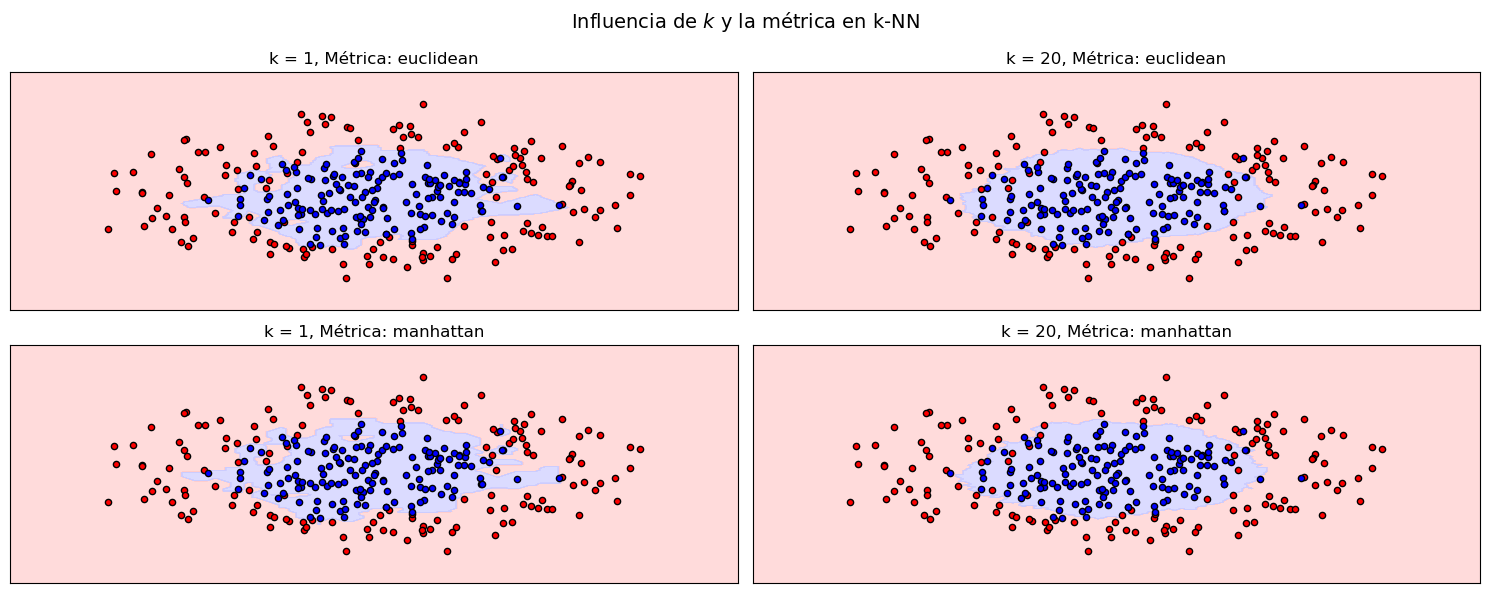

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap


#========================================================================
#  Generar datos no lineales con estructura circular
X, y = make_circles(n_samples=300, noise=0.2, factor=0.4, random_state=0)


#========================================================================
#  Función para graficar la frontera de decisión
def plot_knn_boundaries_metric(X, y, k_values, metrics):
    cmap_light = ListedColormap(['#FFCCCC', '#CCCCFF'])
    cmap_bold = ['red', 'blue']
    
    fig, axes = plt.subplots(len(metrics), len(k_values), figsize=(15, 6))
    
    for i, metric in enumerate(metrics):
        for j, k in enumerate(k_values):
            clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
            clf.fit(X, y)

            # Malla para frontera
            x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
            y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                                 np.linspace(y_min, y_max, 300))
            Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            ax = axes[i, j]
            ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
            for class_value, color in enumerate(cmap_bold):
                ax.scatter(X[y == class_value, 0], X[y == class_value, 1],
                           c=color, edgecolor='k', label=f'Clase {class_value}', s=20)
            ax.set_title(f'k = {k}, Métrica: {metric}')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle('Influencia de $k$ y la métrica en k-NN', fontsize=14)
    plt.tight_layout()
    plt.show()

# 3. Ejecutar para k pequeño y grande, y dos métricas
plot_knn_boundaries_metric(X, y, k_values=[1, 20], metrics=['euclidean', 'manhattan'])


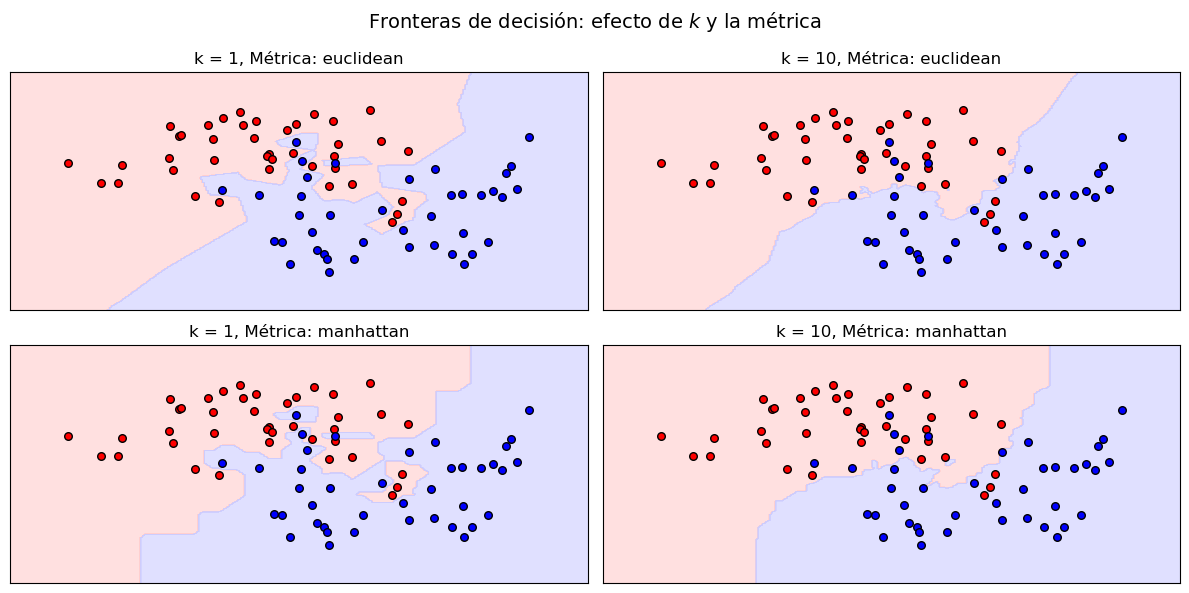

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap


#========================================================================
#  Generar datos dispersos y no lineales
X, y = make_moons(n_samples=80, noise=0.3, random_state=42)


#========================================================================
#  Función para graficar fronteras
def plot_knn_boundaries_metric(X, y, k_values, metrics):
    cmap_light = ListedColormap(['#FFCCCC', '#CCCCFF'])
    cmap_bold = ['red', 'blue']
    
    fig, axes = plt.subplots(len(metrics), len(k_values), figsize=(12, 6))
    
    for i, metric in enumerate(metrics):
        for j, k in enumerate(k_values):
            clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
            clf.fit(X, y)

            # Crear malla para visualizar frontera
            x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
            y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                                 np.linspace(y_min, y_max, 300))
            Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            ax = axes[i, j]
            ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
            for class_value, color in enumerate(cmap_bold):
                ax.scatter(X[y == class_value, 0], X[y == class_value, 1],
                           c=color, edgecolor='k', label=f'Clase {class_value}', s=30)
            ax.set_title(f'k = {k}, Métrica: {metric}')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle('Fronteras de decisión: efecto de $k$ y la métrica', fontsize=14)
    plt.tight_layout()
    plt.show()


#========================================================================
#  Probar con k pequeño y grande, y dos métricas
plot_knn_boundaries_metric(X, y, k_values=[1, 10], metrics=['euclidean', 'manhattan'])


## Arboles de decisión

### Definición formal de los árboles de decisión en clasificación

Un **árbol de decisión** para clasificación es un modelo que define una función de decisión:

$$
h: \mathbb{R}^d \to \{1, 2, \dots, K\}
$$

donde $d$ es el número de características y $K$ el número de clases posibles.  

El algoritmo construye el árbol dividiendo recursivamente el espacio de características mediante **condiciones de decisión** de la forma:

$$
x_j \leq t
$$

donde $x_j$ es una característica y $t$ un umbral.  

En cada nodo, se selecciona la división que maximiza la ganancia de información según un **criterio de impureza**, como:

- **Índice de Gini**:

$$
Gini(S) = 1 - \sum_{k=1}^K p_k^2
$$

- **Entropía**:

$$
H(S) = - \sum_{k=1}^K p_k \log_2(p_k)
$$

donde $p_k$ es la proporción de ejemplos de la clase $k$ en el nodo $S$.  

El proceso termina cuando los nodos son **puros** (solo contienen ejemplos de una clase) o se alcanza una condición de parada (profundidad máxima, mínimo número de muestras, etc.).  
Las **hojas** del árbol asignan la clase mayoritaria de los ejemplos en esa región.


### Ejemplo:

- **Dataset Iris** → Tiene 3 clases de flores (Iris setosa, Iris versicolor, Iris virginica), cada una con 50 muestras, entonces 150 ejemplos de flores, cada una con 4 características (largo/pétalo/sépalo).
- **Entrenamiento/Prueba** → Se divide el conjunto en 70% entrenamiento y 30% prueba.  
- **Árbol de Decisión** → Usa criterio `entropy` (puedes cambiar a `gini`) y profundidad máxima de 3 niveles.  
- **Evaluación** → Se imprime la exactitud y un reporte de métricas (precision, recall, f1-score).  
- **Visualización** → Se dibuja el árbol con nombres de características y clases.


Exactitud: 0.9777777777777777

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



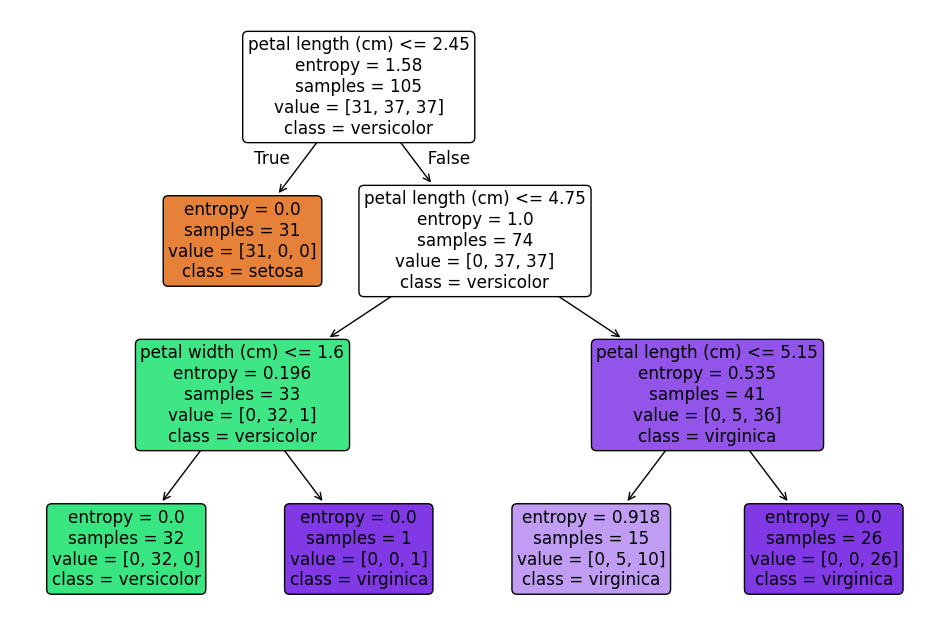

In [9]:
# Árbol de decisión para clasificación
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


#==============================================================================
# Cargar el dataset Iris
iris = load_iris()
X, y = iris.data, iris.target


#==============================================================================
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#==============================================================================
#  Crear y entrenar el árbol de decisión
clf = DecisionTreeClassifier(
    criterion="entropy",   # también se puede usar "gini"
    max_depth=3,           # limitar la profundidad para simplificar
    random_state=42
)
clf.fit(X_train, y_train)


#==============================================================================
#  Predicciones
y_pred = clf.predict(X_test)


#==============================================================================
#  Evaluación del modelo
print("Exactitud:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))


#==============================================================================
#  Visualizar el árbol
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True)
plt.show()


## Random Forest

### Random Forest en Clasificación

El algoritmo **Random Forest** es un método de *ensemble learning* que combina múltiples árboles de decisión para mejorar la capacidad predictiva y reducir el riesgo de sobreajuste (*overfitting*).  

En clasificación, la idea principal es la siguiente:

1. **Muestreo bootstrap**:  
   A partir del conjunto de datos original, se generan subconjuntos de entrenamiento mediante muestreo con reemplazo.

2. **Entrenamiento de múltiples árboles**:  
   Cada subconjunto se usa para entrenar un árbol de decisión. Durante el proceso, en cada nodo, en lugar de considerar todas las características, se selecciona aleatoriamente un subconjunto de ellas.  
   Esto introduce diversidad entre los árboles.

3. **Votación mayoritaria**:  
   Una vez entrenados los árboles, para clasificar una nueva muestra, cada árbol emite un voto sobre la clase.  
   La clase final predicha es aquella que recibe la mayoría de votos.

---

#### Formalización

Dado un conjunto de datos de entrenamiento  
$$
D = \{(x_1, y_1), (x_2, y_2), \dots, (x_N, y_N)\}
$$  

donde $x_i \in \mathbb{R}^d$ representa un vector de características y $y_i \in \{1, 2, \dots, K\}$ representa la clase:  

1. Se generan $B$ subconjuntos $D_b$ mediante *bootstrap sampling*.  
2. Se entrena un árbol de decisión $h_b(x)$ con cada $D_b$, seleccionando aleatoriamente un subconjunto de características en cada división del árbol.  
3. La predicción final se obtiene por votación:  

$$
\hat{y} = \arg \max_{k \in \{1,\dots,K\}} \sum_{b=1}^B \mathbf{1}\{h_b(x) = k\}
$$

donde $\mathbf{1}$ es la función indicadora.  

---

#### Ventajas
- Reduce el sobreajuste en comparación con un único árbol.  
- Maneja bien grandes conjuntos de datos y características ruidosas.  
- Estima la importancia de las variables.  

#### Desventajas
- Menor interpretabilidad que un solo árbol de decisión.  
- Requiere más recursos computacionales. 

## Random Forest con el dataset *Iris*

Este código implementa un modelo de **Random Forest** para clasificar flores del dataset clásico **Iris**.  

---

#### 1. Carga de datos
Se utiliza la función `load_iris()` de *scikit-learn*, que contiene 150 muestras de flores de tres especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada muestra tiene 4 características: 
- longitud del sépalo, 
- ancho del sépalo, 
- longitud del pétalo, 
- ancho del pétalo.  

---

#### 2. División en entrenamiento y prueba
Se divide el dataset en un **70% para entrenamiento** y un **30% para prueba**, asegurando la misma proporción de clases (`stratify=y`).  

---

#### 3. Creación del modelo Random Forest
Se construye un **RandomForestClassifier** con:
- `n_estimators=100`: se entrenan 100 árboles de decisión.  
- `max_depth=3`: cada árbol puede tener como máximo 3 niveles de profundidad.  
- `random_state=42`: garantiza reproducibilidad.  

---

#### 4. Entrenamiento y predicciones
El modelo se entrena con `rf.fit(X_train, y_train)` y luego predice con `rf.predict(X_test)`.  

---

#### 5. Evaluación del modelo
Se calculan métricas de desempeño:  
- **Exactitud** (*accuracy*): proporción de predicciones correctas.  
- **Reporte de clasificación**: incluye *precision*, *recall* y *F1-score* para cada clase.  

---

#### 6. Importancia de características
El modelo asigna un puntaje de importancia a cada característica, indicando cuáles variables son más relevantes para la clasificación.  



Exactitud: 0.9111111111111111

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



C:\Users\Flavio\AppData\Local\Temp\ipykernel_25324\910286740.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


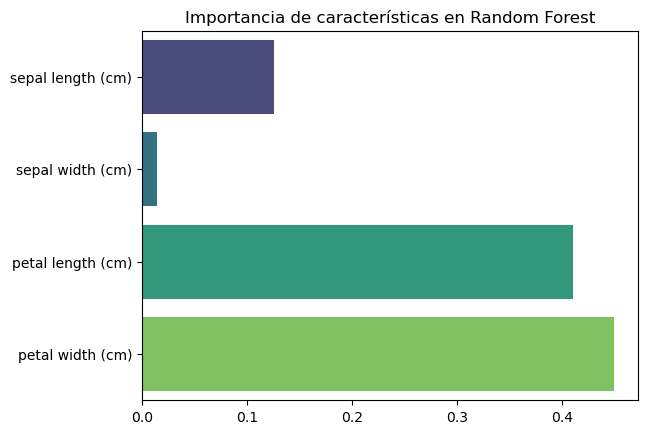

In [10]:
# Random Forest con Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Crear modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=100,   # número de árboles
    max_depth=3,        # profundidad máxima de cada árbol
    random_state=42
)

# Entrenar
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Evaluación
print("Exactitud:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Importancia de características
importances = rf.feature_importances_
features = iris.feature_names

# Mostrar importancias en gráfico
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Importancia de características en Random Forest")
plt.show()


## Efecto del número de estimadores (árboles)

- Con la base de datos Iris

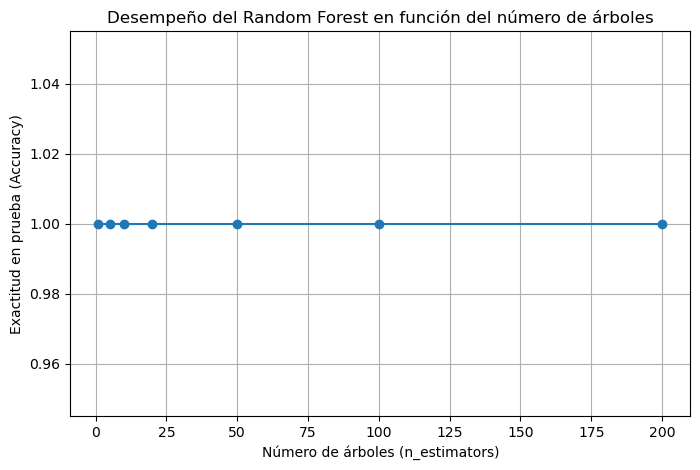

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Valores de número de estimadores a probar
n_estimators_list = [1, 5, 10, 20, 50, 100, 200]

accuracies = []

# Entrenar y evaluar con diferentes n_estimators
for n in n_estimators_list:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Graficar resultados
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracies, marker='o', linestyle='-')
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Exactitud en prueba (Accuracy)")
plt.title("Desempeño del Random Forest en función del número de árboles")
plt.grid(True)
plt.show()


- Con un conjunto de datos más complejo y realista como es el dataset de dígitos escritos a mano (digits) de sklearn, que tiene 1797 imágenes de 8x8 píxeles en 10 clases (dígitos 0–9).

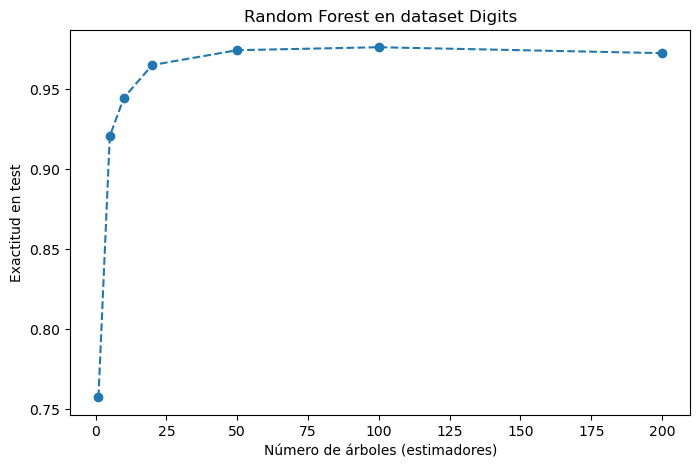

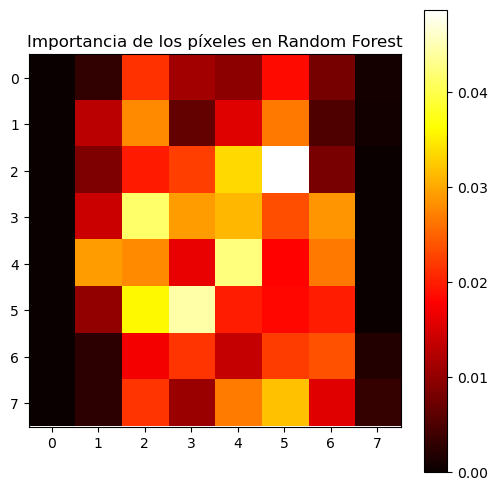

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Cargar dataset de dígitos
digits = load_digits()
X, y = digits.data, digits.target

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Probar diferentes números de árboles
#estimadores = [10, 50, 100, 200, 300]
estimadores = [1, 5, 10, 20, 50, 100, 200]
accuracies = []

for n in estimadores:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Graficar desempeño vs número de árboles
plt.figure(figsize=(8,5))
plt.plot(estimadores, accuracies, marker='o', linestyle='--')
plt.xlabel("Número de árboles (estimadores)")
plt.ylabel("Exactitud en test")
plt.title("Random Forest en dataset Digits")
plt.show()

# Entrenar un modelo final con más árboles
clf_final = RandomForestClassifier(n_estimators=200, random_state=42)
clf_final.fit(X_train, y_train)

# Importancia de características (píxeles)
importances = clf_final.feature_importances_
importances_img = importances.reshape(8, 8)

plt.figure(figsize=(6,6))
plt.imshow(importances_img, cmap="hot", interpolation="nearest")
plt.title("Importancia de los píxeles en Random Forest")
plt.colorbar()
plt.show()


## Dataset Wine

El **dataset Wine** es un conjunto de datos clásico incluido en `scikit-learn`, utilizado comúnmente en problemas de **clasificación**.  
Contiene información química de vinos producidos en la misma región de Italia, pero a partir de **tres diferentes variedades de uva**.

- **Número de muestras:** 178  
- **Número de características:** 13 (todas numéricas y continuas)  
- **Número de clases:** 3 (cada clase corresponde a un tipo (variedad) de uva)

### Características
Las variables (características) medidas son:

1. **Alcohol**  
2. **Malic acid** (ácido málico)  
3. **Ash** (ceniza)  
4. **Alcalinity of ash** (alcalinidad de la ceniza)  
5. **Magnesium** (magnesio)  
6. **Total phenols** (fenoles totales)  
7. **Flavanoids** (flavonoides)  
8. **Nonflavanoid phenols** (fenoles no flavonoides)  
9. **Proanthocyanins** (proantocianinas)  
10. **Color intensity** (intensidad de color)  
11. **Hue** (tono del color)  
12. **OD280/OD315 of diluted wines** (relación de absorbancia a 280 nm y 315 nm)  
13. **Proline** (prolina)  

### Objetivo
El problema consiste en **clasificar el vino en una de las 3 clases** basándose en sus propiedades químicas.  
Este dataset es particularmente útil para probar técnicas de **clasificación supervisada**, **reducción de dimensionalidad** y **análisis de importancia de características**.


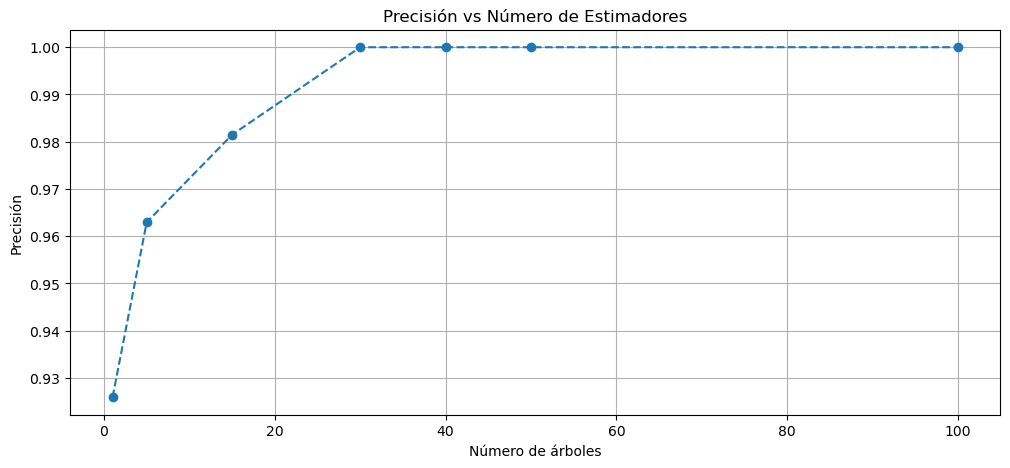

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ------------------------------
# 1. Cargar dataset
# ------------------------------
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names

# ------------------------------
# 2. Dividir datos en entrenamiento y prueba
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ------------------------------
# 3. Evaluar desempeño según n_estimators
# ------------------------------
estimators = [1, 5, 15, 30, 40, 50, 100]
accuracies = []

for n in estimators:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# ------------------------------
# 4. Entrenar modelo final con más árboles
# ------------------------------
clf_final = RandomForestClassifier(n_estimators=200, random_state=42)
clf_final.fit(X_train, y_train)

# ------------------------------
# 5. Importancia de características
# ------------------------------
importances = clf_final.feature_importances_
indices = np.argsort(importances)[::-1]  # ordenar descendentemente

# ------------------------------
# 6. Graficar resultados
# ------------------------------

# Precisión vs número de árboles
plt.figure(figsize=(12,5))

plt.plot(estimators, accuracies, marker="o", linestyle="--")
plt.title("Precisión vs Número de Estimadores")
plt.xlabel("Número de árboles")
plt.ylabel("Precisión")
plt.grid(True)
plt.show()

Exactitud: 1.0

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



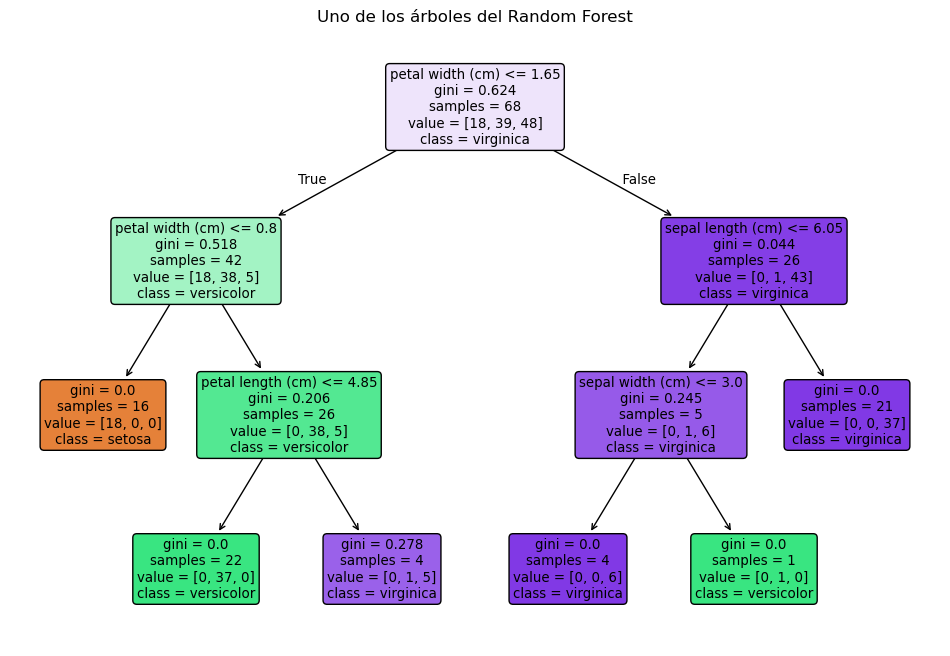

In [44]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report


#==============================================================================
# Cargar el dataset Iris
iris = load_iris()
X, y = iris.data, iris.target


#==============================================================================
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#==============================================================================
# Crear y entrenar el modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=100,     # número de árboles en el bosque
    criterion="gini",     # o "entropy"
    max_depth=3,          # limitar profundidad para visualización
    random_state=42
)

rf.fit(X_train, y_train)


#==============================================================================
# Predicciones
y_pred = rf.predict(X_test)


#==============================================================================
# Evaluación del modelo
print("Exactitud:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n",
      classification_report(y_test, y_pred, target_names=iris.target_names))


#==============================================================================
# Visualizar uno de los árboles del Random Forest
plt.figure(figsize=(12,8))

plot_tree(
    rf.estimators_[0],   # primer árbol del bosque
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Uno de los árboles del Random Forest")
plt.show()

## Random Forest e Importancia de Características

### Mean Decrease in Impurity (MDI)

La técnica **Mean Decrease in Impurity (MDI)**, también conocida como *impurity-based feature importance*, es el método estándar utilizado en **Random Forests** y árboles de decisión para calcular la importancia de las características.

#### Explicación breve
- Cada vez que un nodo de un árbol divide los datos usando una característica, la **impureza** (medida con **Gini** o **Entropía**) se reduce.  
- Esa reducción de impureza se asigna a la característica usada en la división.  
- El proceso se repite en **todos los nodos de todos los árboles** y se **suman las contribuciones**.  
- Finalmente, se **normalizan los valores** para que las importancias sumen 1.  

#### Fórmula

$$
\text{Importancia}(f_j) \;=\; \frac{1}{T} \sum_{t=1}^{T} \; \sum_{n \in N_{j,t}} p(n)\,\Delta i(n)
$$

donde:  

- $T$ = número de árboles  
- $N_{j,t}$ = conjunto de nodos en el árbol $t$ que usan la característica $f_j$  
- $p(n)$ = proporción de muestras que llegan al nodo $n$  
- $\Delta i(n)$ = reducción de impureza generada al dividir en el nodo $n$  

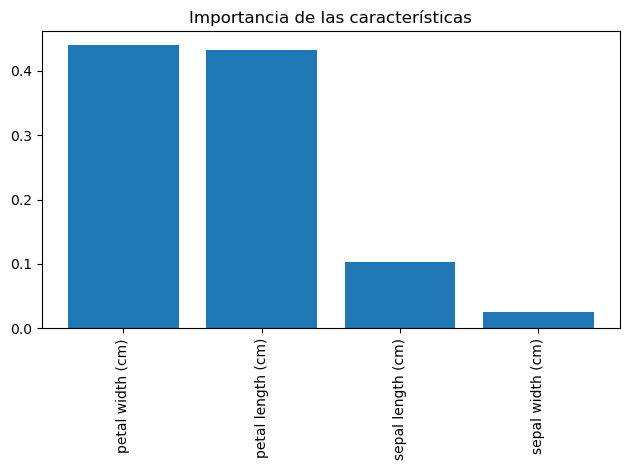

In [15]:
# Obtener importancia de características
importances = rf.feature_importances_

# Ordenar características por importancia
indices = importances.argsort()[::-1]

# Nombres de características
feature_names = iris.feature_names

# Gráfica
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.title("Importancia de las características")
plt.tight_layout()
plt.show()

Exactitud: 1.0

Reporte de Clasificación:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

IMPORTANCIAS: [0.1420413  0.02897616 0.01185922 0.03321121 0.03467347 0.05975795
 0.16594663 0.00547961 0.02977833 0.18019827 0.0859658  0.09603179
 0.12608026]


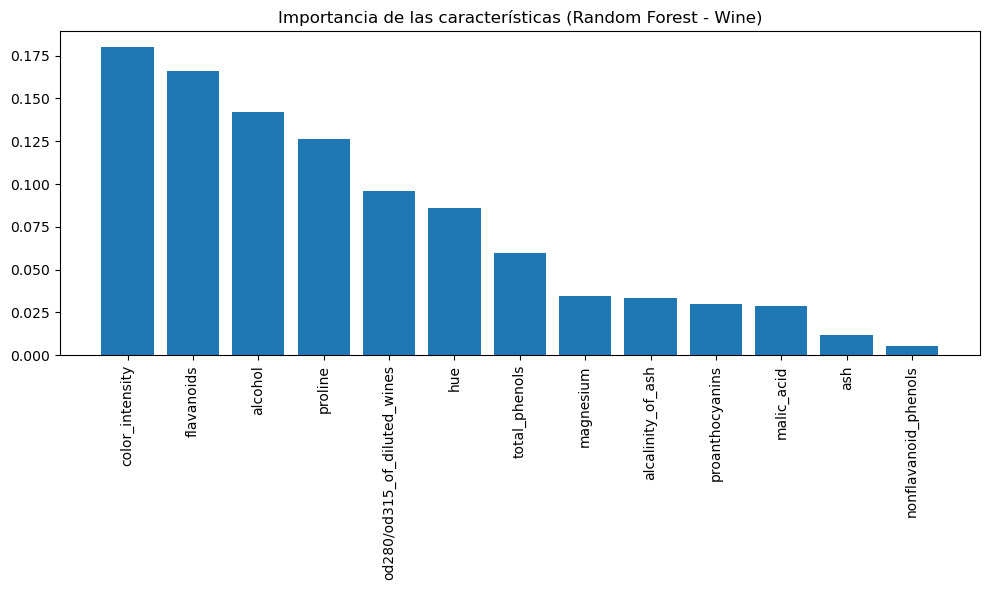

In [16]:
# Random Forest con dataset Wine
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#==============================================================================
# Cargar dataset Wine
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names

#==============================================================================
# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#==============================================================================
# Entrenar Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

#==============================================================================
# Predicciones
y_pred = rf.predict(X_test)

#==============================================================================
# Evaluación
print("Exactitud:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n",
      classification_report(y_test, y_pred, target_names=wine.target_names))

#==============================================================================
# Importancia de características
importances = rf.feature_importances_
print("IMPORTANCIAS:",importances)
indices = importances.argsort()[::-1]

#==============================================================================
# Gráfica de importancia
plt.figure(figsize=(10,6))

plt.bar(range(X.shape[1]), importances[indices], align="center")

plt.xticks(
    range(X.shape[1]),
    [feature_names[i] for i in indices],
    rotation=90
)

plt.title("Importancia de las características (Random Forest - Wine)")
plt.tight_layout()
plt.show()

## Gradient Boosting Machines (GBM) para Clasificación  

La técnica **Gradient Boosting Machines (GBM)** es un método de *ensamble* que combina múltiples clasificadores débiles, usualmente árboles de decisión, para construir un clasificador fuerte.  

La idea central consiste en construir el modelo de manera **aditiva y secuencial**, donde cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores.  

El modelo se expresa como:  

$$
F_M(x) = \sum_{m=1}^M \gamma_m h_m(x),
$$  

donde:  
- $M$ es el número de iteraciones (o árboles).  
- $h_m(x)$ es el clasificador débil en la iteración $m$.  
- $\gamma_m$ es el peso o factor de aprendizaje asignado al clasificador.  

El ajuste de cada árbol se realiza minimizando una función de pérdida diferenciable, por ejemplo, la **log-loss** para clasificación binaria:  

$$
L(y, F(x)) = \log\big(1 + e^{-yF(x)}\big), \quad y \in \{-1, +1\}.
$$  

En cada iteración, el algoritmo calcula los **gradientes negativos** (pseudo-residuos) de la función de pérdida con respecto a las predicciones actuales:  

$$
r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)},
$$  

y posteriormente ajusta un nuevo árbol $h_m(x)$ sobre dichos residuos.  

Finalmente, el modelo se actualiza como:  

$$
F_m(x) = F_{m-1}(x) + \eta \, \gamma_m h_m(x),
$$  

donde $\eta$ es la **tasa de aprendizaje** que controla el aporte de cada árbol.  

En conclusión, el GBM construye un clasificador robusto y flexible, que tiende a lograr un excelente desempeño en tareas de clasificación, especialmente cuando se ajustan cuidadosamente los hiperparámetros como $M$, $\eta$ y la profundidad de los árboles.

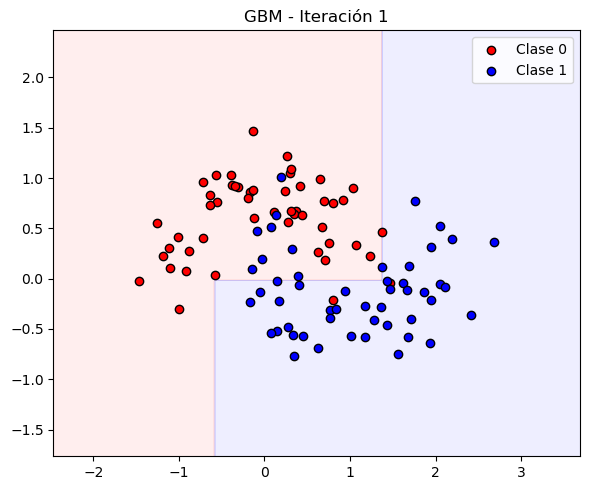

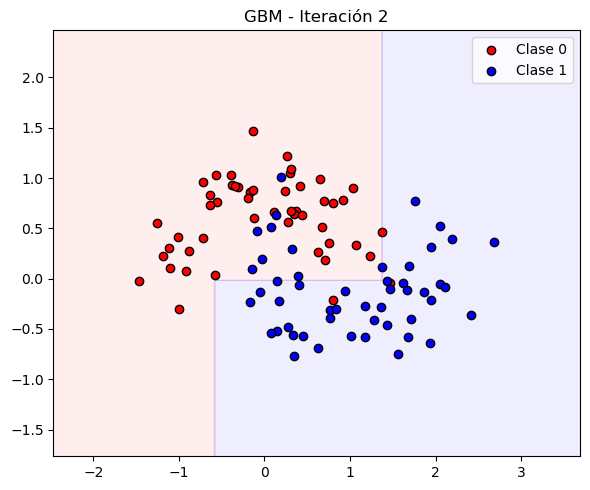

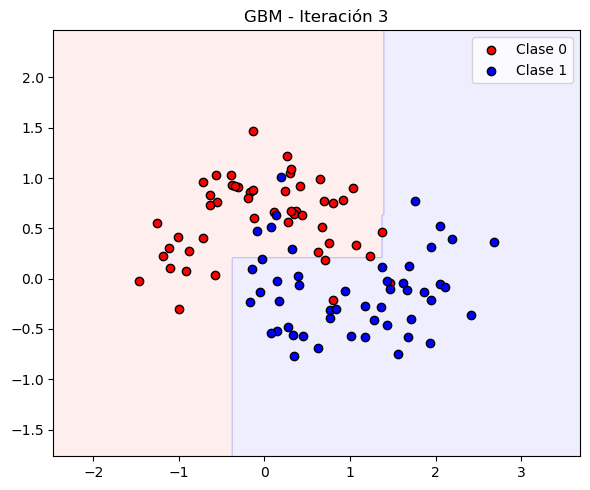

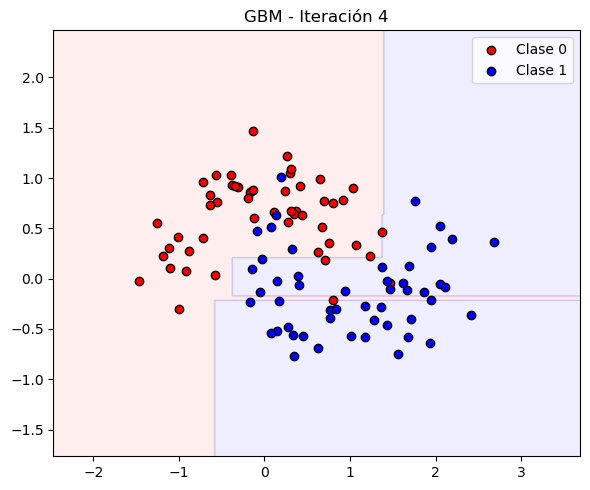

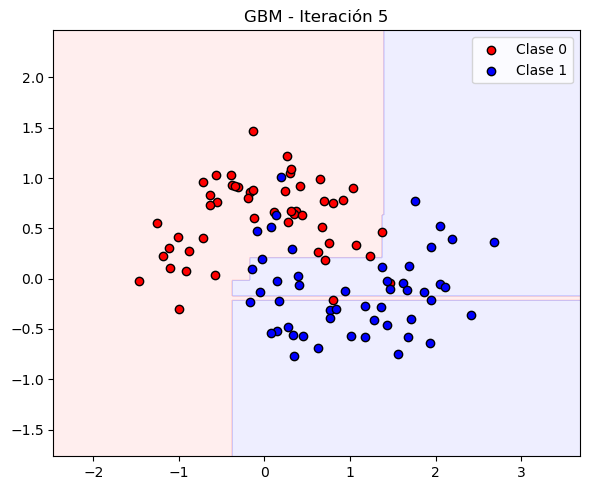

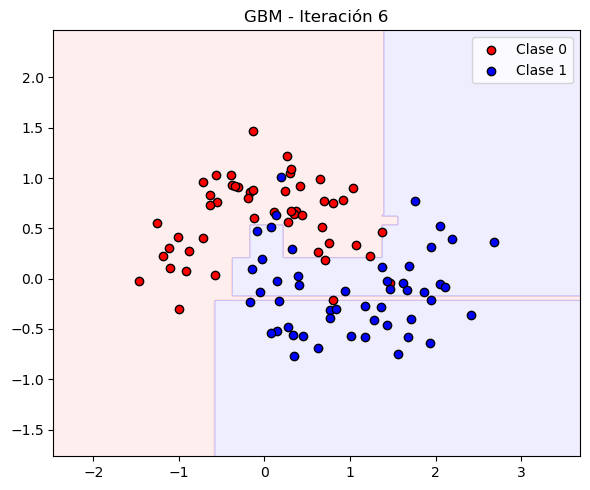

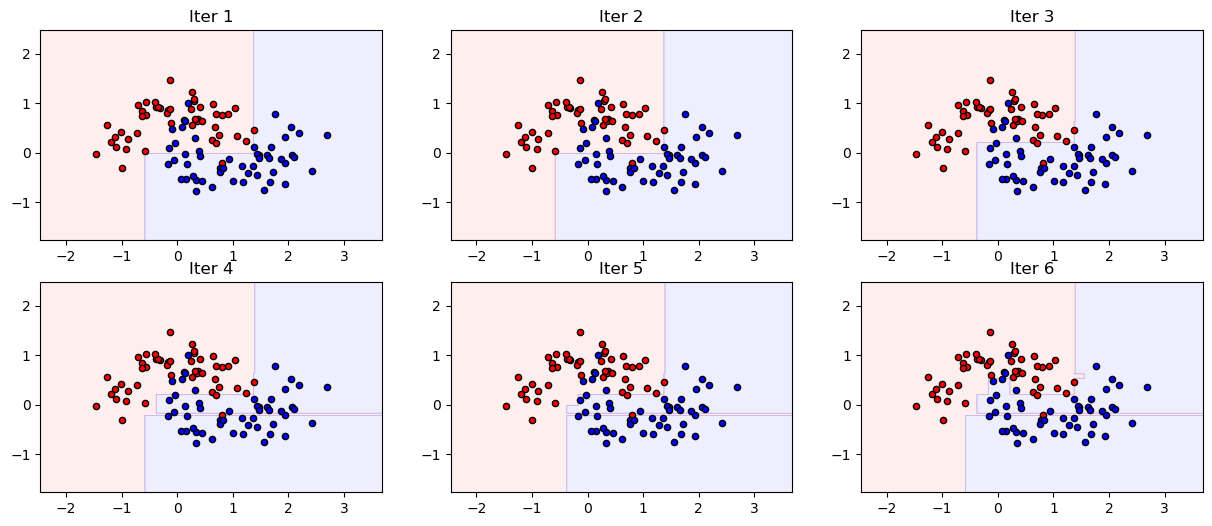

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.datasets import make_moons
from sklearn.ensemble import GradientBoostingClassifier
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm


#====================================================================================
# Generar datos de clasificación binaria
#X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
#                           n_redundant=0, n_clusters_per_class=1, random_state=42)

#====================================================================================
#  Crear conjunto de datos no linealmente separable
X, y = make_moons(n_samples=100, noise=0.25, random_state=42)


#====================================================================================
#  Definir modelo GBM (pocos árboles para ilustrar)
gbm = GradientBoostingClassifier(n_estimators=6, learning_rate=0.5,
                                 max_depth=2, random_state=42)


#====================================================================================
#  Entrenar modelo
gbm.fit(X, y)


#====================================================================================
#  Crear malla para visualizar la frontera de decisión
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))


#====================================================================================
#  Iterar sobre las etapas de boosting
for i, y_pred in enumerate(gbm.staged_predict(np.c_[xx.ravel(), yy.ravel()]), start=1):
    Z = y_pred.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    
    # Datos
    plt.scatter(X[y==0, 0], X[y==0, 1], c="red", edgecolor="k", label="Clase 0")
    plt.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", label="Clase 1")
    
    # Etiquetas
    plt.title(f"GBM - Iteración {i}")
    plt.legend()
    plt.tight_layout()
    
    # Guardar figura de cada paso
    plt.savefig(f"GBM_step_{i}.png", dpi=300)
    plt.show()


#====================================================================================
#  También puedes mostrar todas las etapas en una sola figura
#fig, axes = plt.subplots(1, gbm.n_estimators, figsize=(15, 3))
#for ax, (i, y_pred) in zip(axes, enumerate(gbm.staged_predict(np.c_[xx.ravel(), yy.ravel()]), start=1)):
#    Z = y_pred.reshape(xx.shape)
#    ax.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
#    ax.scatter(X[y==0, 0], X[y==0, 1], c="red", edgecolor="k", s=20)
#    ax.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", s=20)
#    ax.set_title(f"Iter {i}")
#    #ax.set_xticks([]); ax.set_yticks([])
#
#    # mostrar valores en los ejes
#    plt.tight_layout()

# Número máximo de columnas por fila
ncols = 3
nrows = int(np.ceil(gbm.n_estimators / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows))

# Asegurar que axes sea 1D para iterar fácilmente
axes = axes.flatten()

for ax, (i, y_pred) in zip(axes, enumerate(gbm.staged_predict(np.c_[xx.ravel(), yy.ravel()]), start=1)):
    Z = y_pred.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    ax.scatter(X[y==0, 0], X[y==0, 1], c="red", edgecolor="k", s=20)
    ax.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", s=20)
    ax.set_title(f"Iter {i}")
    # ax.set_xticks([]); ax.set_yticks([])

# Quitar los ejes sobrantes si no se llenan todas las casillas
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.savefig("GBM_all_iterations.png", dpi=300)
plt.show()


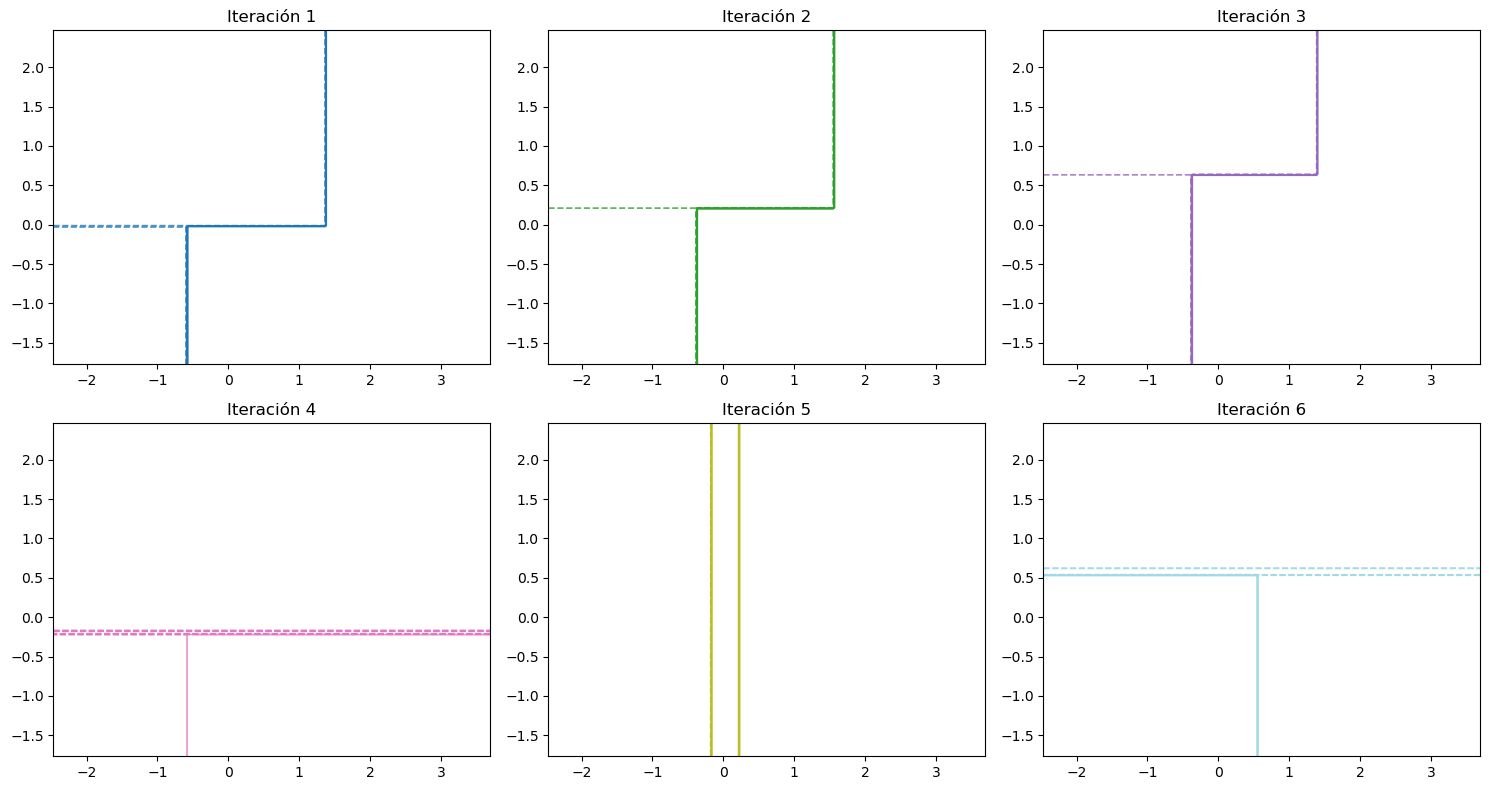

In [18]:

#====================================================================================
#  Número de árboles débiles en el modelo
n_estimators = len(gbm.estimators_)


#====================================================================================
#  Determinar layout de subplots (ej. cuadrícula)
n_cols = 3  # número de columnas que quieras
n_rows = int(np.ceil(n_estimators / n_cols))


#====================================================================================
#  Crear figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))


#====================================================================================
#  Asegurar que axes sea 1D para iterar fácilmente
axes = axes.ravel()


#====================================================================================
#  Crear paleta de colores
colors = cm.tab20(np.linspace(0, 1, n_estimators))

for i, stage in enumerate(gbm.estimators_):
    ax = axes[i]
    
#    # Fondo coloreado según la predicción final del ensamble completo
#    ax.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    
    # Predicción del árbol débil i
    stage_pred = stage[0].predict(np.c_[xx.ravel(), yy.ravel()])
    stage_pred = stage_pred.reshape(xx.shape)
    
    # Dibujar frontera del árbol i
    ax.contour(xx, yy, stage_pred,
               colors=[colors[i]], alpha=0.8, linewidths=1.2)
    
    ## Dibujar los puntos de datos
    #ax.scatter(X[y==0, 0], X[y==0, 1], c="red", edgecolor="k", label="Clase 0", s=30)
    #ax.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", label="Clase 1", s=30)
    
    ax.set_title(f"Iteración {i+1}")


#====================================================================================
#  Eliminar subplots vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Cada **línea** representa la frontera de decisión de un árbol débil individual dentro del Gradient Boosting.

- La línea sólida representa un contorno para un nivel (por ejemplo 1).
- La línea punteada representa el otro nivel (por ejemplo 2).

- Líneas verticales → corresponden a cortes realizados por el árbol a lo largo del eje $x_1$ (usando umbrales en una sola característica).  
- Líneas horizontales → corresponden a cortes realizados por el árbol a lo largo del eje $x_2$.

Esto ocurre porque los árboles de decisión débiles empleados en GBM (normalmente con poca profundidad, como `max_depth = 1` o `max_depth = 2`) dividen el espacio con reglas del tipo:

$$
x_j \leq t
$$

donde $j$ representa una característica (eje horizontal o vertical) y $t$ un umbral.

Por lo tanto:

- Cada segmento horizontal indica una división en función de la característica asociada al eje $y$ (segunda variable).  
- Cada segmento vertical indica una división en función de la característica asociada al eje $x$ (primera variable).  

En resumen:

- El fondo coloreado corresponde a la predicción final combinada del ensamble.  
- Las líneas grises representan las fronteras de decisión intermedias de cada árbol débil.  
- Dichas líneas son horizontales o verticales porque cada árbol divide el espacio según un umbral de una sola característica, sin combinar ambas con inclinación.

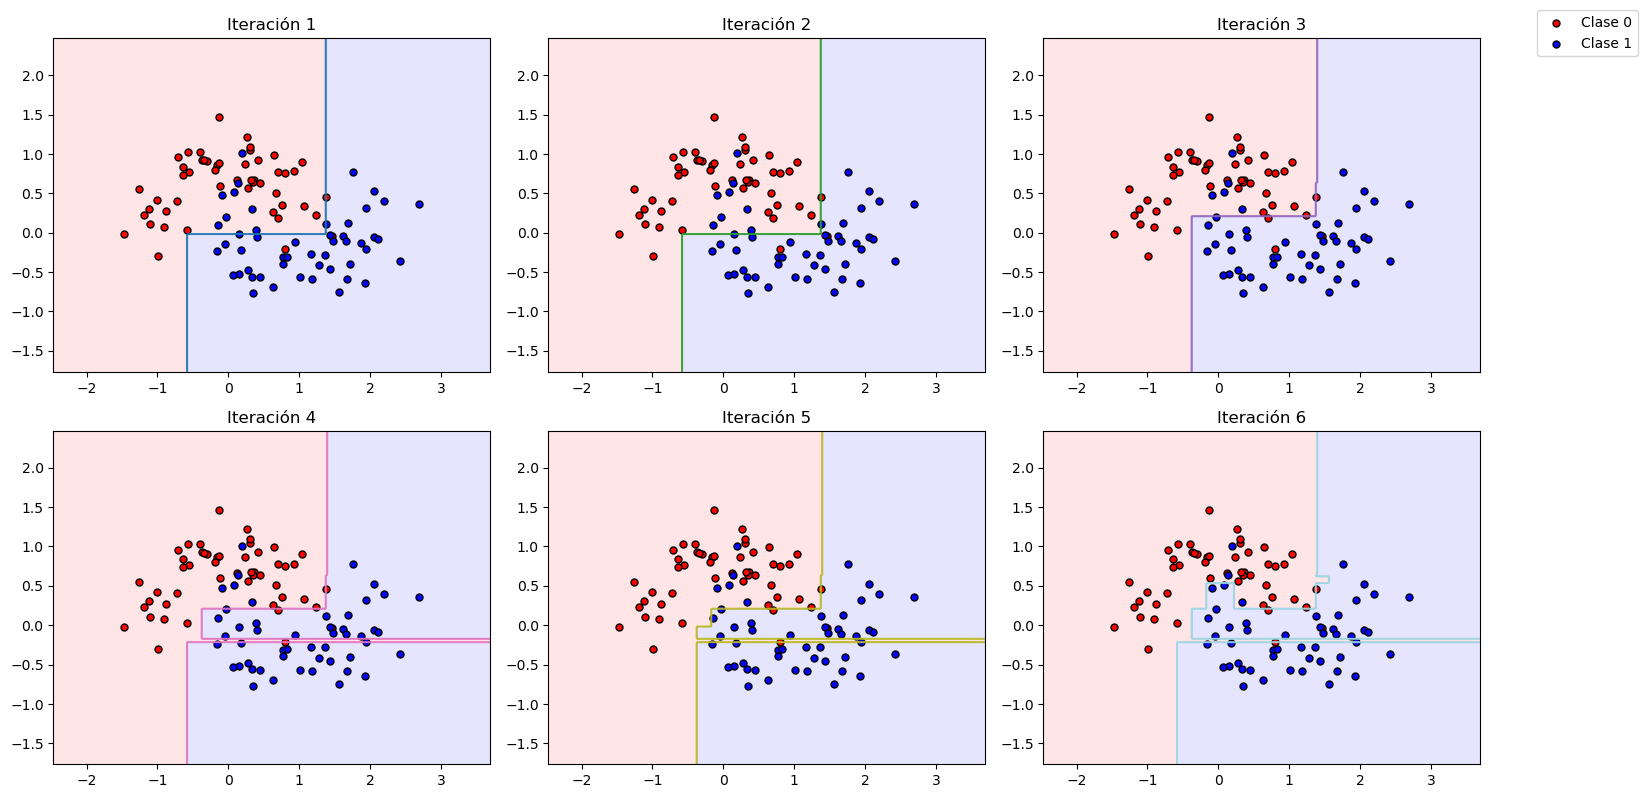

In [19]:

#====================================================================================
#  Número de árboles débiles en el modelo
n_estimators = len(gbm.estimators_)


#====================================================================================
#  Determinar layout de subplots (ej. cuadrícula)
n_cols = 3  # máximo 3 columnas
n_rows = int(np.ceil(n_estimators / n_cols))


#====================================================================================
#  Crear figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.ravel()  # Asegurar que sea 1D


#====================================================================================
#  Colormap para las regiones (Clase 0 = rojo, Clase 1 = azul)
region_cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])


#====================================================================================
#  Paleta de colores para las fronteras
colors = cm.tab20(np.linspace(0, 1, n_estimators))


#====================================================================================
#  Recorrer las predicciones acumuladas (staged_predict)
for i, y_pred in enumerate(gbm.staged_predict(np.c_[xx.ravel(), yy.ravel()])):
    ax = axes[i]
    
    # Dar forma a la predicción acumulada
    stage_pred = y_pred.reshape(xx.shape)
    
    # Colorear regiones acumuladas hasta el árbol i
    ax.contourf(xx, yy, stage_pred, alpha=0.3, cmap=region_cmap)
    
    # Dibujar frontera del modelo acumulado
    ax.contour(xx, yy, stage_pred, levels=[0.5],
               colors=[colors[i]], alpha=0.9, linewidths=1.5)
    
    # Dibujar los puntos de datos
    ax.scatter(X[y==0, 0], X[y==0, 1], c="red", edgecolor="k", s=25, label="Clase 0" if i==0 else "")
    ax.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", s=25, label="Clase 1" if i==0 else "")
    
    ax.set_title(f"Iteración {i+1}")


#====================================================================================
#  Eliminar subplots vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


#====================================================================================
#  Leyenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()


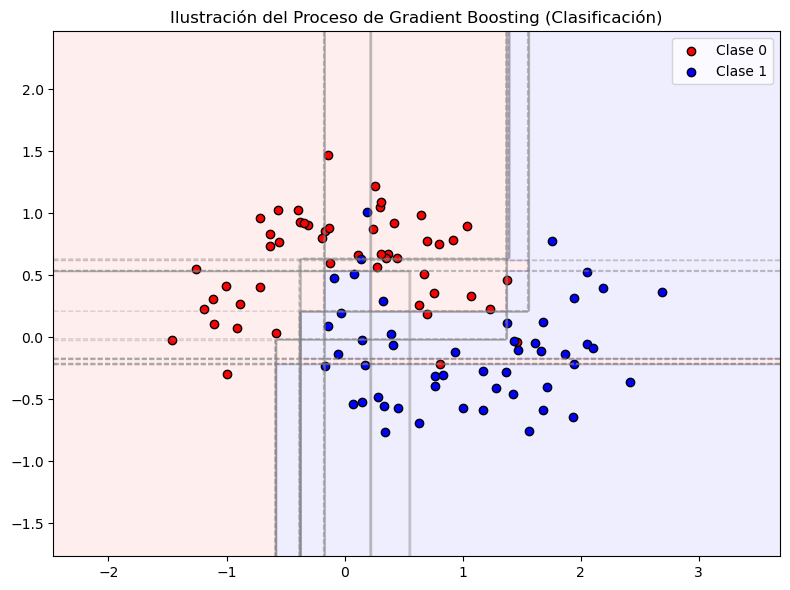

In [20]:

#====================================================================================
#  Crear la figura
plt.figure(figsize=(8, 6))


#====================================================================================
# Fondo coloreado según la predicción final
plt.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))


#====================================================================================
#  Mostrar cada estimador intermedio (árbol débil)
for i, stage in enumerate(gbm.estimators_):
    # La predicción de cada árbol débil
    stage_pred = stage[0].predict(np.c_[xx.ravel(), yy.ravel()])
    stage_pred = stage_pred.reshape(xx.shape)
    plt.contour(xx, yy, stage_pred, colors="gray", alpha=0.3, linewidths=1)


#====================================================================================
#  Dibujar los datos
plt.scatter(X[y==0, 0], X[y==0, 1], c="red", edgecolor="k", label="Clase 0")
plt.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", label="Clase 1")

# Añadir etiquetas
plt.title("Ilustración del Proceso de Gradient Boosting (Clasificación)")
plt.legend()
plt.tight_layout()

# Guardar la figura
plt.savefig("GBM_Classification.png", dpi=300)
plt.show()


## Naive Bayes

La técnica **Naive Bayes** es un método de clasificación probabilístico basado en el **Teorema de Bayes**, que asume independencia condicional entre las características dado el valor de la clase. Esta suposición simplifica enormemente el cálculo de probabilidades conjuntas y permite construir modelos de manera eficiente, incluso con un gran número de atributos.  

Dado un vector de características $\mathbf{x} = (x_1, x_2, \dots, x_n)$ y un conjunto de clases posibles $\mathcal{C} = \{C_1, C_2, \dots, C_k\}$, el modelo predice la clase más probable usando:

$$
\hat{y} = \arg \max_{C_j \in \mathcal{C}} P(C_j \mid \mathbf{x})
$$

Aplicando el Teorema de Bayes:

$$
P(C_j \mid \mathbf{x}) = \frac{P(C_j) \, P(\mathbf{x} \mid C_j)}{P(\mathbf{x})}
$$

Bajo la **asunción de independencia condicional** de las características:

$$
P(\mathbf{x} \mid C_j) = \prod_{i=1}^{n} P(x_i \mid C_j)
$$

Por lo tanto, la regla de decisión se reduce a:

$$
\hat{y} = \arg \max_{C_j \in \mathcal{C}} P(C_j) \prod_{i=1}^{n} P(x_i \mid C_j)
$$

Existen variantes de Naive Bayes según el tipo de datos:  

- **Gaussian Naive Bayes:** para variables continuas, asumiendo distribución normal.  
- **Multinomial Naive Bayes:** para conteos o frecuencias de ocurrencias (común en texto).  
- **Bernoulli Naive Bayes:** para variables binarias.  

En conclusión, **Naive Bayes** es un clasificador simple pero sorprendentemente efectivo, especialmente en problemas de alta dimensionalidad, gracias a su eficiencia computacional y capacidad de generalización.

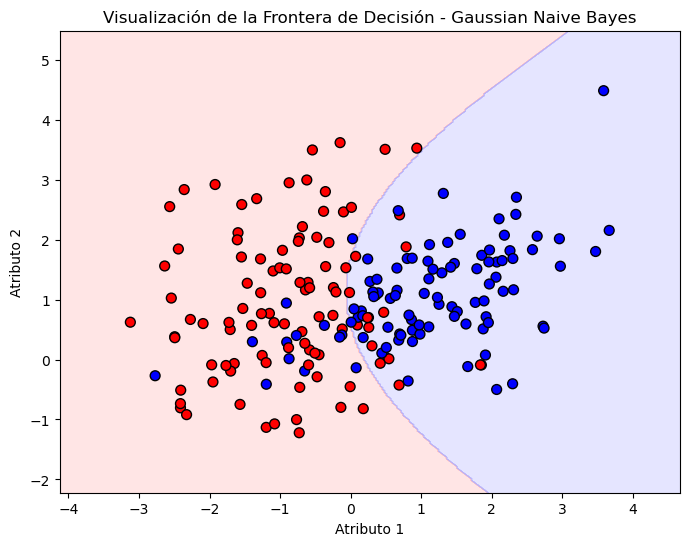

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from matplotlib.colors import ListedColormap


#===============================================================================
# Generar datos de ejemplo 2D
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           random_state=42)

#===============================================================================
#  Entrenar Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X, y)

#===============================================================================
#  Crear malla para evaluar frontera de decisión
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#===============================================================================
#  Graficar frontera de decisión y puntos de entrenamiento
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_points = ListedColormap(['#FF0000', '#0000FF'])

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolor='k', s=50)
plt.title("Visualización de la Frontera de Decisión - Gaussian Naive Bayes")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.show()


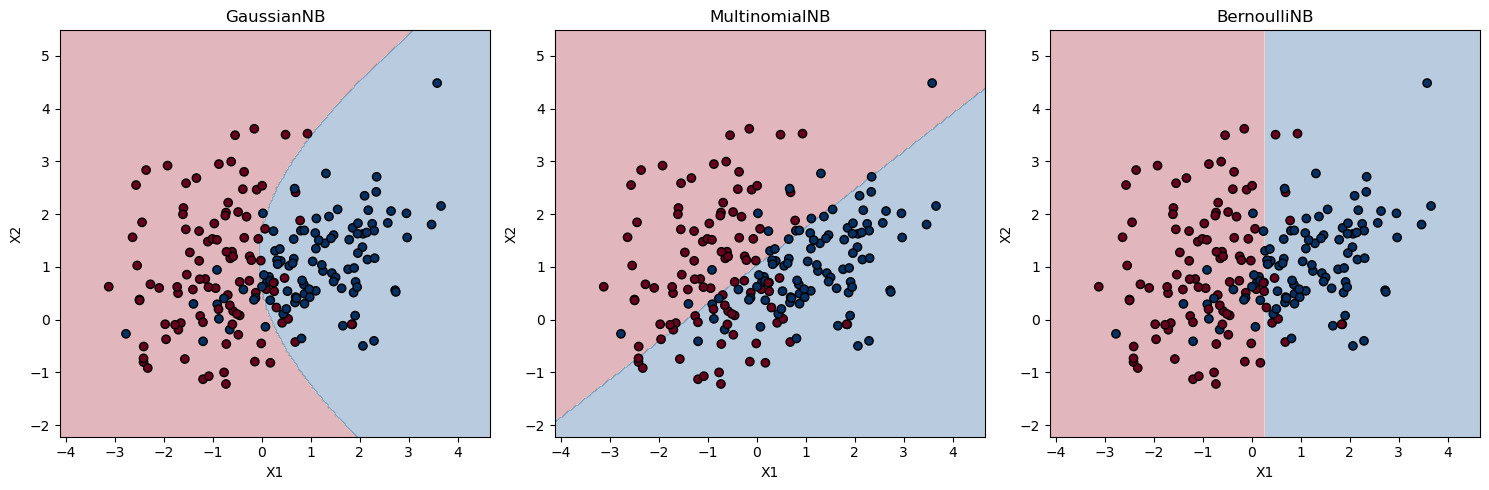

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler, Binarizer

# ---------------------------
# Generar dataset sintético
# ---------------------------
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, random_state=42
)

# Escalar X para multinomial y bernoulli (requiere datos >= 0)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Binarizar para BernoulliNB
binarizer = Binarizer(threshold=0.5)
X_binary = binarizer.fit_transform(X_scaled)

# ---------------------------
# Definir clasificadores
# ---------------------------
classifiers = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB()
}

# Datos a usar para cada clasificador
X_dict = {
    "GaussianNB": X,
    "MultinomialNB": X_scaled,
    "BernoulliNB": X_binary
}

# ---------------------------
# Crear malla para visualización
# ---------------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# ---------------------------
# Graficar fronteras de decisión
# ---------------------------
plt.figure(figsize=(15,5))

for i, (name, clf) in enumerate(classifiers.items(), 1):
    X_train = X_dict[name]
    clf.fit(X_train, y)
    
    # Predecir sobre la malla
    if name == "GaussianNB":
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    else:  # Multinomial y Bernoulli requieren datos escalados o binarios
        # Ajustar escala/binarización de la malla
        if name == "MultinomialNB":
            mesh = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
        else:
            mesh = binarizer.transform(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
        Z = clf.predict(mesh)
    
    Z = Z.reshape(xx.shape)
    
    plt.subplot(1, 3, i)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(name)
    plt.xlabel("X1")
    plt.ylabel("X2")

plt.tight_layout()
plt.show()


### Multinomial Naive bayes

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# ================================
# Paso Dataset
# ================================
texts = [
    "gato juega en el jardin",
    "perro come hueso",
    "gato duerme en el sofa",
    "perro protege la casa",
    "gato y perro son amigos",
    "perro ladra fuerte",
    "gato salta alto"
]

labels = ["gato", "perro", "gato", "perro", "gato", "perro", "gato"]

# ================================
# Paso Vectorización (vocabulario automático)
# ================================
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

print("Vocabulario:", vectorizer.get_feature_names_out())

# ================================
# Paso Entrenar Naive Bayes
# ================================
model = MultinomialNB(alpha=1.0)  # Laplace smoothing
model.fit(X, labels)

# ================================
# Paso Probabilidades a priori
# ================================
print("\nProbabilidades a priori:")
for clase, prob in zip(model.classes_, model.class_log_prior_):
    print(f"P({clase}) = {round(np.exp(prob), 3)}")

# ================================
# Paso Clasificar nuevo documento
# ================================
doc_test = ["gato persigue raton"]
X_test = vectorizer.transform(doc_test)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nDocumento:", doc_test[0])
print("Predicción:", pred[0])

print("\nProbabilidades por clase:")
for clase, p in zip(model.classes_, probs[0]):
    print(f"{clase}: {p:.6f}")

Vocabulario: ['alto' 'amigos' 'casa' 'come' 'duerme' 'el' 'en' 'fuerte' 'gato' 'hueso'
 'jardin' 'juega' 'la' 'ladra' 'perro' 'protege' 'salta' 'sofa' 'son']

Probabilidades a priori:
P(gato) = 0.571
P(perro) = 0.429

Documento: gato persigue raton
Predicción: gato

Probabilidades por clase:
gato: 0.843023
perro: 0.156977


In [24]:
# ================================
# Paso Clasificar nuevo documento
# ================================
doc_test = ["perro corre en el parque"]
X_test = vectorizer.transform(doc_test)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nDocumento:", doc_test[0])
print("Predicción:", pred[0])

print("\nProbabilidades por clase:")
for clase, p in zip(model.classes_, probs[0]):
    print(f"{clase}: {p:.6f}")


Documento: perro corre en el parque
Predicción: gato

Probabilidades por clase:
gato: 0.758247
perro: 0.241753


In [25]:
# ================================
# Paso Clasificar nuevo documento
# ================================
doc_test = ["perro juega con pelota"]
X_test = vectorizer.transform(doc_test)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nDocumento:", doc_test[0])
print("Predicción:", pred[0])

print("\nProbabilidades por clase:")
for clase, p in zip(model.classes_, probs[0]):
    print(f"{clase}: {p:.6f}")


Documento: perro juega con pelota
Predicción: perro

Probabilidades por clase:
gato: 0.463872
perro: 0.536128


### Bernoulli Naive Bayes

In [26]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB

# ================================
# Paso Dataset
# ================================
texts = [
    "gato juega en el jardin",
    "perro come hueso",
    "gato duerme en el sofa",
    "perro protege la casa",
    "gato y perro son amigos",
    "perro ladra fuerte",
    "gato salta alto"
]

labels = ["gato", "perro", "gato", "perro", "gato", "perro", "gato"]

# ================================
# Paso Vectorización binaria
# ================================
vectorizer = CountVectorizer(binary=True)  # 👈 clave: presencia/ausencia
X = vectorizer.fit_transform(texts)

print("Vocabulario:", vectorizer.get_feature_names_out())
print("\nMatriz binaria (0 = no aparece, 1 = aparece):\n", X.toarray())

# ================================
# Paso Entrenar modelo BernoulliNB
# ================================
model = BernoulliNB(alpha=1.0)  # Laplace smoothing
model.fit(X, labels)

# ================================
# Paso Probabilidades a priori
# ================================
print("\nProbabilidades a priori:")
for clase, logp in zip(model.classes_, model.class_log_prior_):
    print(f"P({clase}) = {np.exp(logp):.3f}")

# ================================
# Paso Clasificación
# ================================
doc_test = ["gato persigue raton"]
X_test = vectorizer.transform(doc_test)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nDocumento:", doc_test[0])
print("Predicción:", pred[0])

print("\nProbabilidades por clase:")
for clase, p in zip(model.classes_, probs[0]):
    print(f"{clase}: {p:.6f}")

Vocabulario: ['alto' 'amigos' 'casa' 'come' 'duerme' 'el' 'en' 'fuerte' 'gato' 'hueso'
 'jardin' 'juega' 'la' 'ladra' 'perro' 'protege' 'salta' 'sofa' 'son']

Matriz binaria (0 = no aparece, 1 = aparece):
 [[0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0]]

Probabilidades a priori:
P(gato) = 0.571
P(perro) = 0.429

Documento: gato persigue raton
Predicción: gato

Probabilidades por clase:
gato: 0.943732
perro: 0.056268


In [27]:
# ================================
# Paso Clasificación
# ================================
doc_test = ["perro corre en el parque"]
X_test = vectorizer.transform(doc_test)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nDocumento:", doc_test[0])
print("Predicción:", pred[0])

print("\nProbabilidades por clase:")
for clase, p in zip(model.classes_, probs[0]):
    print(f"{clase}: {p:.6f}")


Documento: perro corre en el parque
Predicción: gato

Probabilidades por clase:
gato: 0.626478
perro: 0.373522


In [28]:
# ================================
# Paso Clasificación
# ================================
doc_test = ["perro juega con pelota"]
X_test = vectorizer.transform(doc_test)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nDocumento:", doc_test[0])
print("Predicción:", pred[0])

print("\nProbabilidades por clase:")
for clase, p in zip(model.classes_, probs[0]):
    print(f"{clase}: {p:.6f}")


Documento: perro juega con pelota
Predicción: perro

Probabilidades por clase:
gato: 0.173316
perro: 0.826684


# **REGRESIÓN**
---

## Regresión Lineal

La **regresión lineal** es una técnica de aprendizaje supervisado utilizada para modelar la relación entre una o más variables independientes $ \mathbf{x} $ y una variable dependiente $ y $, asumiendo que esta relación es lineal.

En su forma más simple (una variable), el modelo se expresa como:

$$
y = wx + b
$$

Donde:
- $ y $: variable dependiente (respuesta)
- $ x $: variable independiente (predictor)
- $ w $: coeficiente de regresión (pendiente)
- $ b $: término independiente (intercepto)

En su forma multivariable:

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b
$$

El objetivo del entrenamiento es encontrar los parámetros $ \mathbf{w} $ y $ b $ que minimicen el **error cuadrático medio (MSE)**:

$$
\mathcal{L}(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2
$$

Este modelo es ampliamente utilizado por su simplicidad, interpretabilidad y eficiencia para problemas de predicción continua.



Ecuación de la recta: y = 2.94·x + 1.91

Para x = 2.50, el valor predicho es ŷ = 9.27





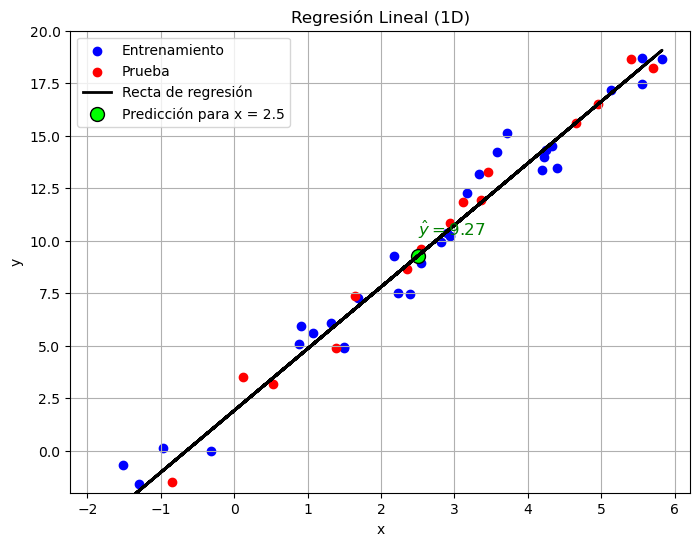

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


#=======================================================================================
# Generar datos
np.random.seed(0)
X = np.random.uniform(-2, 6, size=(50, 1))  # valores de entrada en [−2, 6]
y = 3 * X.squeeze() + 2 + np.random.normal(0, 1, size=50)  # salida con ruido


#=======================================================================================
#  Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)


#=======================================================================================
#  Entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)


#=======================================================================================
#  Mostrar ecuación del modelo
w = model.coef_[0]
b = model.intercept_
print(f"\n\nEcuación de la recta: y = {w:.2f}·x + {b:.2f}")


#=======================================================================================
#  Punto de prueba específico
x_nuevo = np.array([[2.5]])
y_pred = model.predict(x_nuevo)
print(f"\nPara x = {x_nuevo[0][0]:.2f}, el valor predicho es ŷ = {y_pred[0]:.2f}")
print(f"\n\n")


#=======================================================================================
#  Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test, color='red', label='Prueba')
plt.plot(X, model.predict(X), color='black', linewidth=2, label='Recta de regresión')

# Punto nuevo resaltado
plt.scatter(x_nuevo, y_pred, color='lime', s=100, edgecolor='black', label='Predicción para x = 2.5')
plt.text(x_nuevo, y_pred + 1, f"$\\hat{{y}} = {y_pred[0]:.2f}$", fontsize=12, color='green')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Lineal (1D)')
plt.legend()
plt.grid(True)
plt.ylim(-2, 20)  # Eje y entre -2 y 20
plt.show()


## Support Vector Regression (SVR)

**Support Vector Regression (SVR)** es una extensión del algoritmo de Máquinas de Vectores de Soporte (SVM) para tareas de regresión. En lugar de buscar un hiperplano que separe clases, SVR busca una función que aproxime los datos con una tolerancia $\varepsilon$ en torno a las salidas reales.

### Objetivo de SVR:

Encontrar una función de la forma:

$$
f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b
$$

que prediga $y$ con un error máximo de $\varepsilon$, permitiendo algunas desviaciones controladas por variables de holgura $\xi_i, \xi_i^*$.

### Problema de optimización (forma primal):

Minimizar la complejidad del modelo y el error fuera del margen:

$$
\min_{\mathbf{w}, b, \xi_i, \xi_i^*} \quad \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)
$$

sujeto a:

$$
\begin{cases}
y_i - \mathbf{w}^T \mathbf{x}_i - b \leq \varepsilon + \xi_i \\
\mathbf{w}^T \mathbf{x}_i + b - y_i \leq \varepsilon + \xi_i^* \\
\xi_i, \xi_i^* \geq 0
\end{cases}
$$

- $C$: parámetro de regularización que controla el equilibrio entre el ancho del margen $\varepsilon$ y los errores permitidos.
- $\varepsilon$: define el tubo de tolerancia alrededor de la predicción.

### Forma dual:

Utilizando multiplicadores de Lagrange, se obtiene el problema dual:

$$
\begin{aligned}
\max_{\alpha_i, \alpha_i^*} \quad 
& -\frac{1}{2} \sum_{i,j=1}^n (\alpha_i - \alpha_i^*)(\alpha_j - \alpha_j^*) K(\mathbf{x}_i, \mathbf{x}_j) \\
& + \varepsilon \sum_{i=1}^n (\alpha_i + \alpha_i^*) - \sum_{i=1}^n y_i (\alpha_i - \alpha_i^*)
\end{aligned}
$$

sujeto a:

$$
\sum_{i=1}^n (\alpha_i - \alpha_i^*) = 0, \quad 0 \leq \alpha_i, \alpha_i^* \leq C
$$

- $K(\mathbf{x}_i, \mathbf{x}_j)$: función kernel (lineal, RBF, etc.) que permite trabajar en espacios de alta dimensión.

### Predicción:

La función regresora es:

$$
f(\mathbf{x}) = \sum_{i=1}^n (\alpha_i - \alpha_i^*) K(\mathbf{x}_i, \mathbf{x}) + b
$$

Solo los puntos con $\alpha_i \ne \alpha_i^*$ (vectores de soporte) contribuyen al modelo final.

---

**SVR permite construir modelos de regresión robustos** que toleran errores pequeños y son especialmente útiles cuando se desea controlar la complejidad del modelo y el margen de error aceptable.

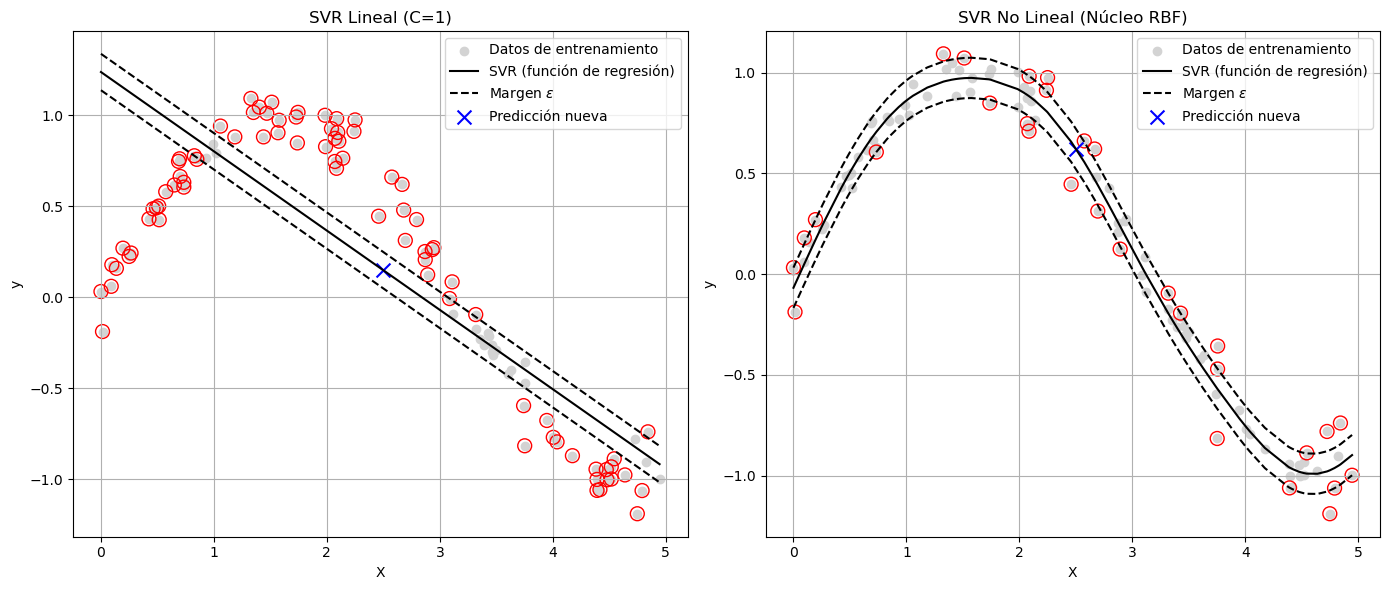

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR


#=======================================================================================
#   Generar datos (relación no lineal)
np.random.seed(1)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + 0.1 * np.random.randn(100)


#=======================================================================================
#   Modelos SVR lineal y RBF con menor C en lineal
svr_lin = SVR(kernel='linear', C=1, epsilon=0.1)  # C reducido para menos vectores de soporte
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.5, epsilon=0.1)

y_lin = svr_lin.fit(X, y).predict(X)
y_rbf = svr_rbf.fit(X, y).predict(X)


#=======================================================================================
#   Punto nuevo a predecir
X_new = np.array([[2.5]])
y_new_lin = svr_lin.predict(X_new)
y_new_rbf = svr_rbf.predict(X_new)


#=======================================================================================
#   Graficar ambos modelos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

def plot_svr(ax, X, y, y_pred, model, title, X_new, y_new):
    ax.scatter(X, y, color='lightgray', label='Datos de entrenamiento')
    ax.plot(X, y_pred, 'k', label='SVR (función de regresión)')
    ax.plot(X, y_pred + model.epsilon, 'k--', label=r'Margen $\varepsilon$')
    ax.plot(X, y_pred - model.epsilon, 'k--')
    
    # Mostrar solo los vectores de soporte que coinciden con datos originales
    for sv in model.support_:
        ax.scatter(X[sv], y[sv], facecolors='none', edgecolors='red', s=100)

    # Punto nuevo predicho
    ax.scatter(X_new, y_new, color='blue', s=100, marker='x', label='Predicción nueva')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)

# SVR Lineal
plot_svr(axs[0], X, y, y_lin, svr_lin, 'SVR Lineal (C=1)', X_new, y_new_lin)

# SVR RBF
plot_svr(axs[1], X, y, y_rbf, svr_rbf, 'SVR No Lineal (Núcleo RBF)', X_new, y_new_rbf)

plt.tight_layout()
plt.show()


## **Regresión con K-Nearest Neighbors (KNN)**

La **regresión KNN** (_K-Nearest Neighbors Regressor_) es una técnica no paramétrica que estima el valor de salida para una entrada $\mathbf{x}$ nueva como el promedio (o una combinación ponderada) de los valores de salida de sus $k$ vecinos más cercanos en el conjunto de entrenamiento.

### ¿Cómo funciona?

Dado un nuevo punto $\mathbf{x}$, el algoritmo:

1. Calcula la distancia entre $\mathbf{x}$ y todos los puntos del conjunto de entrenamiento (usualmente distancia Euclidiana).
2. Selecciona los $k$ vecinos más cercanos.
3. Predice el valor $\hat{y}$ como el promedio de los valores de esos $k$ vecinos:

$$
\hat{y}(\mathbf{x}) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(\mathbf{x})} y_i
$$

donde $\mathcal{N}_k(\mathbf{x})$ es el conjunto de los $k$ vecinos más cercanos a $\mathbf{x}$.

---

### Elección del parámetro $k$

- **$k$ pequeño** (por ejemplo, $k=1$): la predicción se adapta muy bien a los datos de entrenamiento, pero puede sobreajustar (alta varianza, bajo sesgo).
- **$k$ grande** (por ejemplo, $k=15$): las predicciones son más suaves, pero pueden subajustar el patrón real (alto sesgo, baja varianza).

---

### Ventajas y desventajas

**Ventajas**:
- Simple de implementar.
- No asume una forma funcional fija entre entrada y salida.

**Desventajas**:
- Sensible al ruido y a la escala de las variables.
- El costo computacional puede ser alto con grandes cantidades de datos.
- Requiere seleccionar adecuadamente $k$ y una métrica de distancia apropiada.

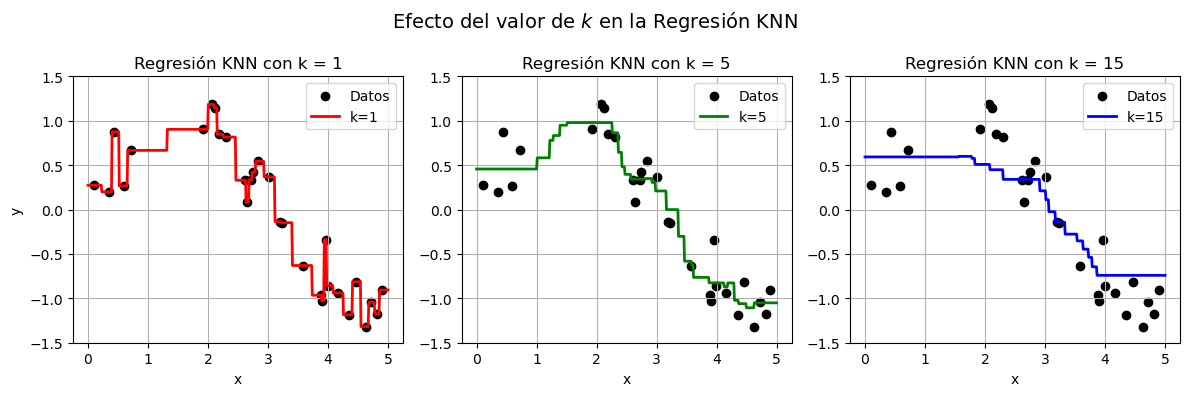

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor


#=======================================================================================
#   Generar datos de regresión ruidosos y dispersos
np.random.seed(0)
X = np.sort(5 * np.random.rand(30, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])


#=======================================================================================
#   Crear conjunto de prueba para visualizar la curva
X_test = np.linspace(0, 5, 500).reshape(-1, 1)


#=======================================================================================
#   Probar diferentes valores de k
k_values = [1, 5, 15]
colors = ['red', 'green', 'blue']

plt.figure(figsize=(12, 4))
for i, k in enumerate(k_values):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X, y)
    y_pred = knn.predict(X_test)

    plt.subplot(1, len(k_values), i + 1)
    plt.scatter(X, y, color='black', label='Datos', edgecolors='k')
    plt.plot(X_test, y_pred, color=colors[i], lw=2, label=f'k={k}')
    plt.ylim(-1.5, 1.5)
    plt.title(f'Regresión KNN con k = {k}')
    plt.xlabel('x')
    if i == 0:
        plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.suptitle('Efecto del valor de $k$ en la Regresión KNN', fontsize=14)
plt.tight_layout()
plt.show()


### Aplicación en 2D

La regresión KNN también puede aplicarse cuando la entrada es bidimensional (por ejemplo, $x_1$ y $x_2$). En estos casos, la superficie estimada se ajusta a los datos en función de la forma y densidad de los vecinos, mostrando superficies más irregulares para $k$ pequeños y más suaves para $k$ grandes.

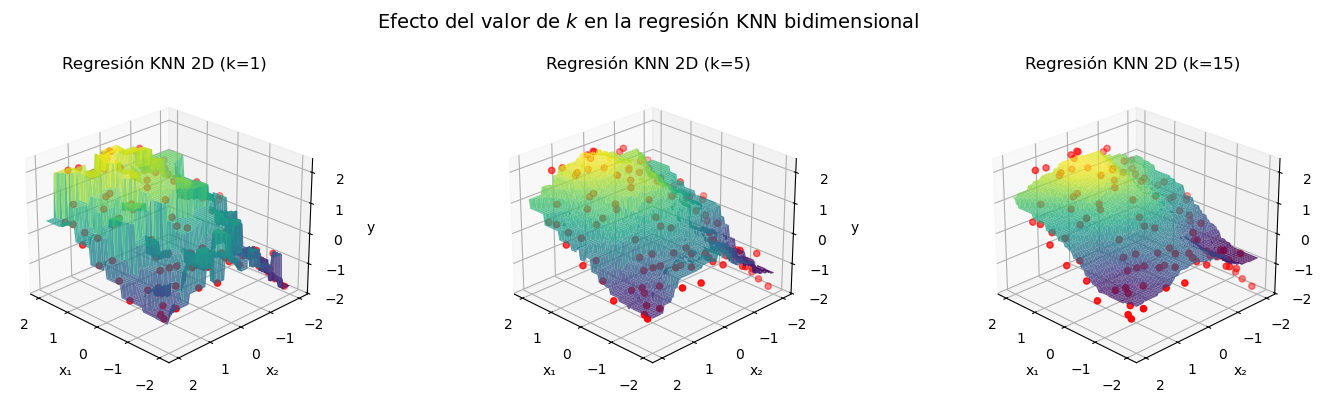

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor


#=======================================================================================
#   Generar datos dispersos en 2D
np.random.seed(1)
X = np.random.rand(100, 2) * 4 - 2  # valores entre [-2, 2]
y = np.sin(X[:, 0]) + np.cos(X[:, 1]) + np.random.normal(0, 0.3, 100)


#=======================================================================================
#   Crear malla para graficar la superficie
xx, yy = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
grid = np.c_[xx.ravel(), yy.ravel()]


#=======================================================================================
#   Visualizar para diferentes valores de k
k_values = [1, 5, 15]
fig = plt.figure(figsize=(15, 4))

for i, k in enumerate(k_values):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X, y)
    zz = model.predict(grid).reshape(xx.shape)

    ax = fig.add_subplot(1, len(k_values), i + 1, projection='3d')
    ax.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], y, color='r', s=20, label='Datos')
    ax.set_title(f'Regresión KNN 2D (k={k})')
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_zlabel('y')
    ax.view_init(elev=25, azim=135)

plt.suptitle('Efecto del valor de $k$ en la regresión KNN bidimensional', fontsize=14)
plt.tight_layout()
plt.show()


## Regresión con **Arboles de decisión**

## Regresión con **Arboles de decisión**

La **regresión con árboles de decisión** es un método de aprendizaje supervisado que utiliza una estructura de árbol binario para predecir un valor numérico continuo.  

Un árbol de decisión divide recursivamente el espacio de las características en regiones más pequeñas, buscando minimizar la **suma de errores cuadrados** en cada partición.  

---

### Criterio de partición

En un nodo con datos $\{(x_i, y_i)\}_{i=1}^N$, el árbol selecciona una característica $j$ y un umbral $t$ que minimizan:

$$
\min_{j,t} \Bigg[ \sum_{x_i \in R_1(j,t)} (y_i - \bar{y}_{R_1})^2 \;+\; \sum_{x_i \in R_2(j,t)} (y_i - \bar{y}_{R_2})^2 \Bigg]
$$

donde:

- $R_1(j,t) = \{x_i \mid x_{ij} \leq t\}$  
- $R_2(j,t) = \{x_i \mid x_{ij} > t\}$  
- $\bar{y}_{R_k}$ es el promedio de las $y_i$ en la región $R_k$.  

---

### Predicción

Una vez construido el árbol, la **predicción para una nueva muestra $x$** se obtiene asignándola a la región correspondiente y tomando el valor promedio de las observaciones en esa hoja:

$$
\hat{y}(x) = \frac{1}{|R(x)|} \sum_{x_i \in R(x)} y_i
$$

donde $R(x)$ es la hoja a la que pertenece la muestra $x$.  

---

### Control de complejidad

- **Profundidad máxima ($max\_depth$)**: controla el número de divisiones sucesivas.  
- **Mínimo de muestras por hoja ($min\_samples\_leaf$)**: evita hojas con muy pocos datos.  
- **Mínimo de muestras para dividir ($min\_samples\_split$)**: establece el mínimo necesario para crear un nodo interno.  

---

En resumen, los **árboles de decisión para regresión** generan predicciones en forma de **funciones escalonadas**, donde cada partición del espacio tiene un valor constante igual al promedio de los datos en esa región.

### Árbol de Decisión para Regresión

En este ejemplo se construye un árbol de decisión para predecir el valor de una variable continua.  
Se generan datos artificiales (tamaño de una casa vs precio) y se ajusta un árbol de regresión.  
La predicción resultante tiene forma de **función escalonada**, ya que cada región del espacio de entrada recibe como salida el promedio de los valores en esa región.


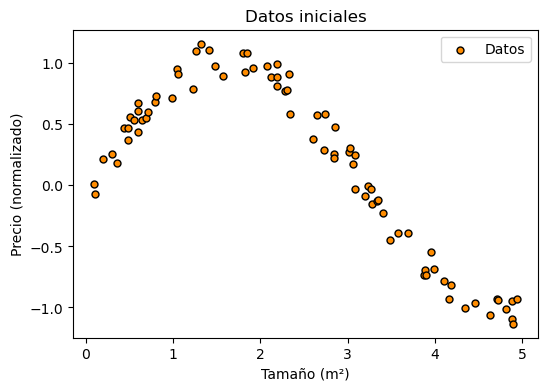

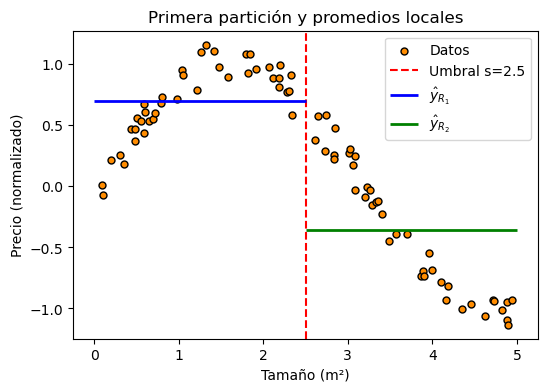

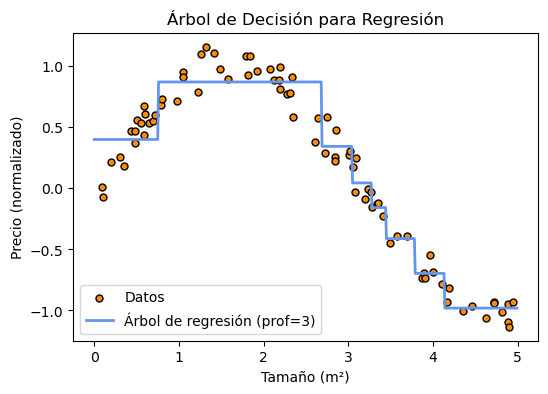

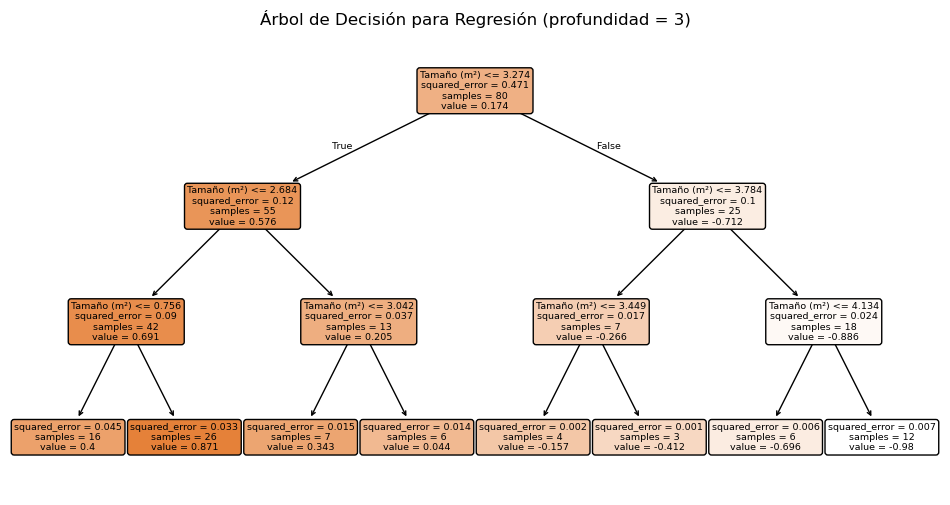

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# ------------------------------
# Generación de datos
# ------------------------------
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + 0.1 * np.random.randn(80)

# ------------------------------
# Gráfico inicial de los datos
# ------------------------------
plt.figure(figsize=(6,4))
plt.scatter(X, y, s=25, edgecolor="black", c="darkorange", label="Datos")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (normalizado)")
plt.title("Datos iniciales")
plt.legend()
plt.show()

# ------------------------------
# Primera partición ilustrativa
# ------------------------------
s = 2.5
R1 = (X.ravel() <= s)
R2 = (X.ravel() > s)
y_R1 = np.mean(y[R1])
y_R2 = np.mean(y[R2])

plt.figure(figsize=(6,4))
plt.scatter(X, y, s=25, edgecolor="black", c="darkorange", label="Datos")
plt.axvline(s, color="red", linestyle="--", label=f"Umbral s={s}")
plt.hlines(y_R1, xmin=0, xmax=s, colors="blue", linewidth=2, label=r"$\hat{y}_{R_1}$")
plt.hlines(y_R2, xmin=s, xmax=5, colors="green", linewidth=2, label=r"$\hat{y}_{R_2}$")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (normalizado)")
plt.title("Primera partición y promedios locales")
plt.legend()
plt.show()

# ------------------------------
# Árbol de regresión entrenado
# ------------------------------
Profundidad = 3
reg = DecisionTreeRegressor(max_depth=Profundidad)
reg.fit(X, y)

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = reg.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(X, y, s=25, edgecolor="black", c="darkorange", label="Datos")
plt.plot(X_test, y_pred, color="cornflowerblue", linewidth=2, label="Árbol de regresión (prof=3)")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (normalizado)")
plt.title("Árbol de Decisión para Regresión")
plt.legend()
plt.show()


# ------------------------------
# Mostrar el árbol de decisión final
# ------------------------------
plt.figure(figsize=(12,6))
plot_tree(reg, feature_names=["Tamaño (m²)"], filled=True, rounded=True)
plt.title(f"Árbol de Decisión para Regresión (profundidad = {Profundidad})")
plt.show()


### Ejemplo

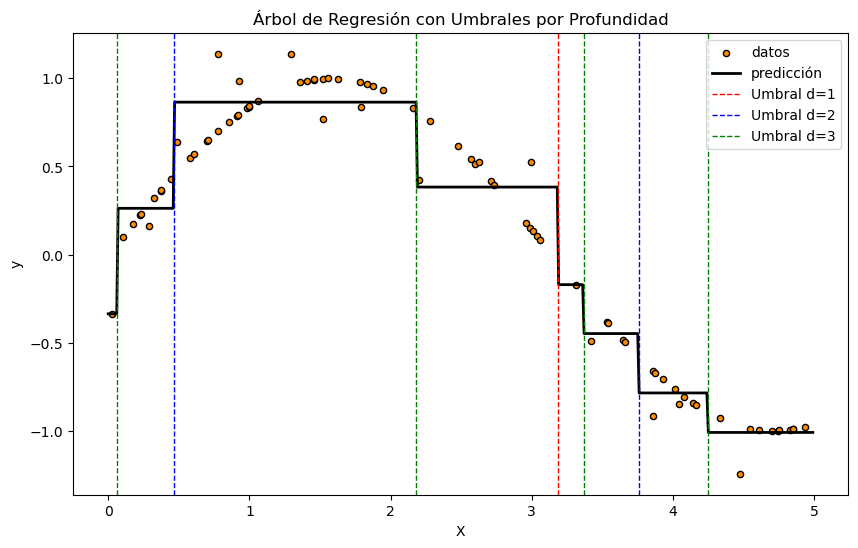

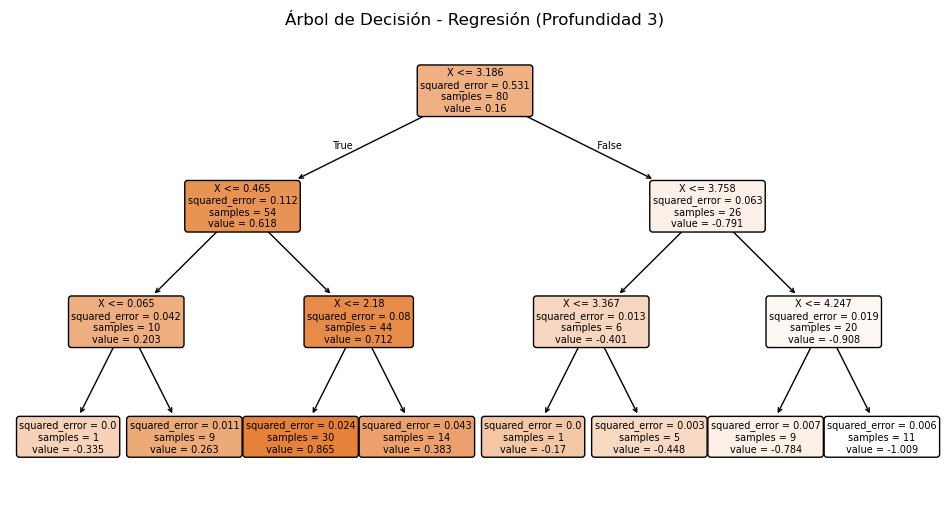

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree


#=======================================================================================
#   Datos de ejemplo
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 0.5 - np.random.rand(16)  # ruido


#=======================================================================================
#   Entrenar árbol de regresión con profundidad 3
reg = DecisionTreeRegressor(max_depth=3)
reg.fit(X, y)


#=======================================================================================
#   Crear grilla para predecir
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = reg.predict(X_test)


#=======================================================================================
#   Graficar datos y regresión
plt.figure(figsize=(10,6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="datos")
plt.plot(X_test, y_pred, color="black", linewidth=2, label="predicción")


#=======================================================================================
#   Recorrer nodos del árbol y graficar thresholds
n_nodes = reg.tree_.node_count
children_left = reg.tree_.children_left
children_right = reg.tree_.children_right
threshold = reg.tree_.threshold


#=======================================================================================
#   Función recursiva para recorrer y pintar thresholds según profundidad
def plot_thresholds(node_id=0, depth=0):
    if children_left[node_id] != children_right[node_id]:  # nodo interno
        thr = threshold[node_id]
        color = {0:"red", 1:"blue", 2:"green"}.get(depth, "gray")
        plt.axvline(x=thr, color=color, linestyle="--", linewidth=1, 
                    label=f"Umbral d={depth+1}" if f"Umbral d={depth+1}" not in plt.gca().get_legend_handles_labels()[1] else "")
        # Llamar recursivamente en hijos
        plot_thresholds(children_left[node_id], depth+1)
        plot_thresholds(children_right[node_id], depth+1)

plot_thresholds()

plt.xlabel("X")
plt.ylabel("y")
plt.title("Árbol de Regresión con Umbrales por Profundidad")
plt.legend()
plt.show()

# Graficar el árbol de decisión
plt.figure(figsize=(12,6))
plot_tree(reg, filled=True, feature_names=["X"], rounded=True)
plt.title("Árbol de Decisión - Regresión (Profundidad 3)")
plt.show()


## **Random Forest** como Regresor

El **Random Forest Regressor** es una técnica de *ensemble learning* que combina múltiples árboles de decisión para mejorar la precisión y reducir el sobreajuste. La idea central es entrenar muchos árboles de decisión independientes sobre subconjuntos aleatorios de datos y características, y luego promediar sus predicciones.

### Construcción del modelo
1. **Muestreo bootstrap**: Se seleccionan muestras aleatorias con reemplazo del conjunto de datos original.
2. **Subconjunto de características**: Para cada nodo de un árbol, se selecciona aleatoriamente un subconjunto de características, lo que introduce diversidad entre los árboles.
3. **Árboles independientes**: Cada árbol se entrena de manera independiente.
4. **Promedio**: La predicción final es el promedio de las predicciones individuales de los árboles.

### Predicción
Si se tienen $T$ árboles de decisión, cada uno produce una predicción $h_t(x)$ para una entrada $x$.  
La predicción del bosque aleatorio se calcula como:

$$
\hat{y}(x) = \frac{1}{T} \sum_{t=1}^T h_t(x)
$$

### Función de costo
Cada árbol de regresión busca minimizar el **Error Cuadrático Medio (MSE)** en los nodos al realizar las particiones:

$$
MSE = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2
$$

donde:
- $y_i$ es el valor real,
- $\hat{y}_i$ es la predicción del modelo,
- $N$ es el número de muestras.

### Ventajas
- Reduce el sobreajuste respecto a un único árbol.
- Robusto frente a ruido en los datos.
- Capaz de modelar relaciones no lineales.

### Desventajas
- Menos interpretable que un único árbol.
- Puede ser computacionalmente costoso para grandes conjuntos de datos.

### *EJEMPLO* con datos sintéticos

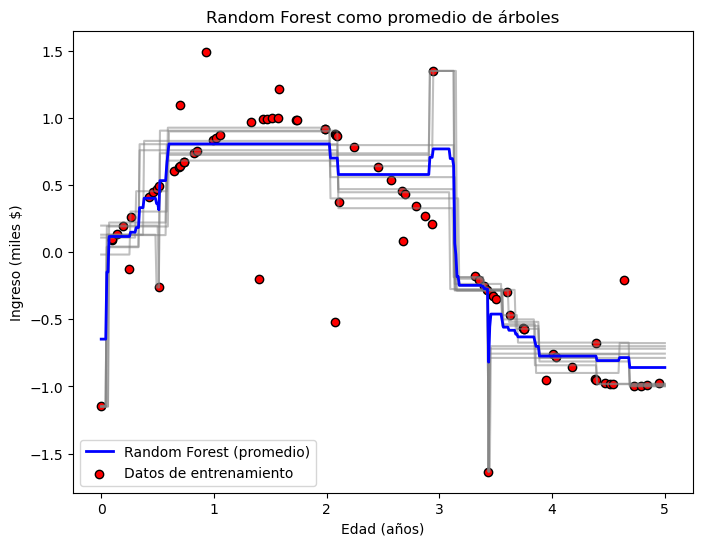

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor


#=======================================================================================
#   Datos de ejemplo
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))  # añadir ruido


#=======================================================================================
#   Definir árboles base (random forest simple)
n_estimators = 10
Profundidad = 3
estimators = []
for _ in range(n_estimators):
    sample_idx = rng.choice(len(X), len(X), replace=True)
    X_sample, y_sample = X[sample_idx], y[sample_idx]
    tree = DecisionTreeRegressor(max_depth=Profundidad)
    tree.fit(X_sample, y_sample)
    estimators.append(tree)


#=======================================================================================
#   Predicciones
X_test = np.linspace(0, 5, 500).reshape(-1, 1)
y_preds = np.zeros((n_estimators, len(X_test)))

for i, tree in enumerate(estimators):
    y_preds[i] = tree.predict(X_test)

y_mean = y_preds.mean(axis=0)


#=======================================================================================
#   Graficar
plt.figure(figsize=(8, 6))
for i in range(n_estimators):
    plt.plot(X_test, y_preds[i], color="gray", alpha=0.5)

plt.plot(X_test, y_mean, color="blue", linewidth=2, label="Random Forest (promedio)")
plt.scatter(X, y, c="red", edgecolor="k", label="Datos de entrenamiento")
plt.legend()
plt.xlabel("Edad (años)")
plt.ylabel("Ingreso (miles $)")
plt.title("Random Forest como promedio de árboles")
plt.savefig("fig/Latex/RandomForestReg.png", dpi=300)
plt.show()


### Random Forest Regressor – Ilustración con datos sintéticos

Este código muestra cómo varía el desempeño de un **Random Forest Regressor** al aumentar el número de árboles (`n_estimators`).  

### Flujo del código
1. **Generación de datos sintéticos**  
   - Se generan 100 puntos aleatorios en el rango $[0,5]$.  
   - La función verdadera a aproximar es $y = \sin(x)$.  
   - A los datos se les agrega ruido gaussiano para simular observaciones reales.  

2. **Conjunto de prueba**  
   - Se define una malla de 500 puntos (`X_test`) para evaluar suavemente la función real y la predicción del modelo.  

3. **Entrenamiento y evaluación con distintos `n_estimators`**  
   - Se entrena un `RandomForestRegressor` con $n \in \{1, 5, 20, 100\}$ árboles.  
   - Para cada modelo, se predice sobre `X_test` y se calcula el **Error Cuadrático Medio (MSE)** respecto a la función real $\sin(x)$.  

4. **Visualización**  
   - En cada subgráfico se muestran:  
     - Los datos observados (azul).  
     - La función real $y=\sin(x)$ (verde).  
     - La predicción del Random Forest (rojo).  
   - El título indica el número de árboles y el error MSE correspondiente.  

### Idea principal
- Con **pocos árboles** (ej. `n=1` o `n=5`), la predicción es ruidosa y no captura bien la forma de la función.  
- A medida que se incrementa el número de estimadores, el modelo logra una aproximación más suave y el **MSE disminuye**.  
- Esto ilustra cómo el ensamble de árboles en Random Forest **reduce la varianza** y mejora la capacidad de generalización.  


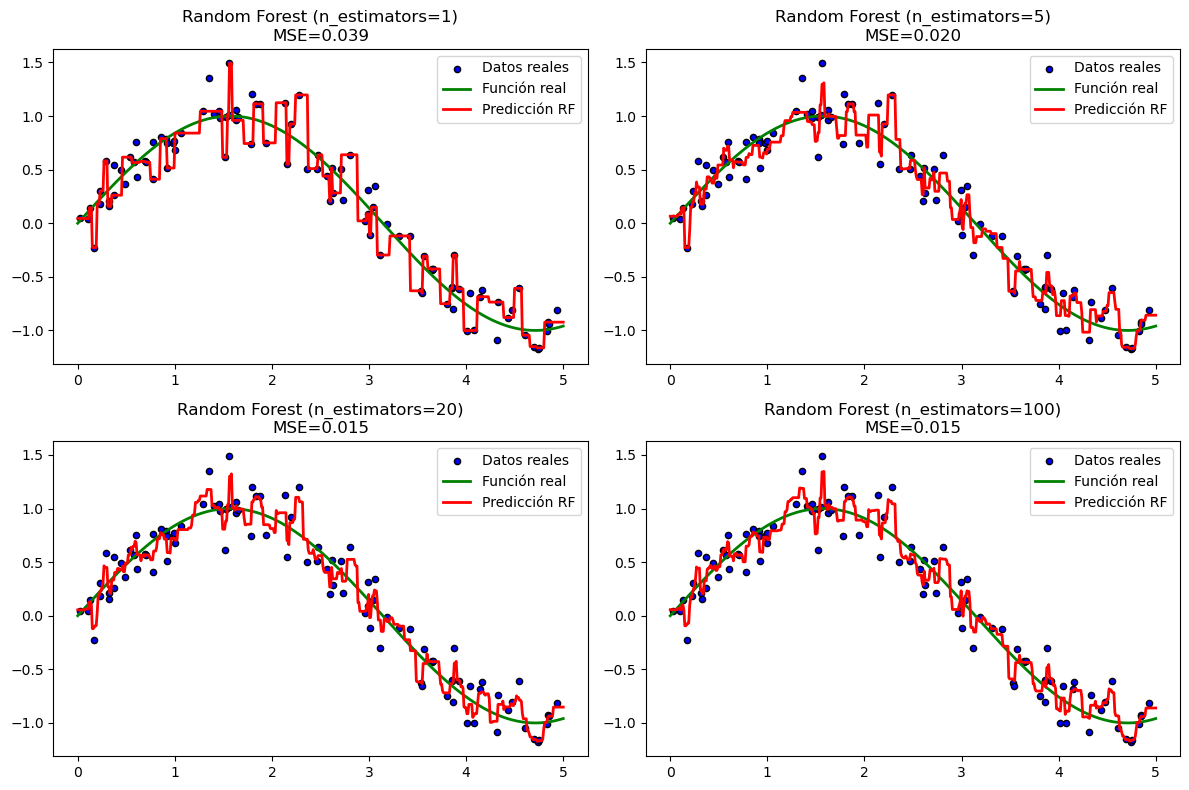

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


#=======================================================================================
#   Generar datos sintéticos (función no lineal + ruido)
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)   # datos en [0,5]
y_true_function = np.sin(X).ravel()               # función base
y = y_true_function + np.random.normal(0, 0.2, len(X))  # función + ruido

# Puntos para predicción suave
X_test = np.linspace(0, 5, 500).reshape(-1, 1)
y_true = np.sin(X_test).ravel()

# Diferentes valores de n_estimators
n_estimators_list = [1, 5, 20, 100]

plt.figure(figsize=(12, 8))

for i, n in enumerate(n_estimators_list, 1):
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X, y)
    y_pred = rf.predict(X_test)

    # Calcular error MSE
    mse = mean_squared_error(y_true, y_pred)

    # Visualización
    plt.subplot(2, 2, i)
    plt.scatter(X, y, s=20, edgecolor="k", c="blue", label="Datos reales")
    plt.plot(X_test, y_true, color="green", linewidth=2, label="Función real")
    plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicción RF")
    plt.title(f"Random Forest (n_estimators={n})\nMSE={mse:.3f}")
    plt.legend()

plt.tight_layout()
plt.show()


### Desempeño

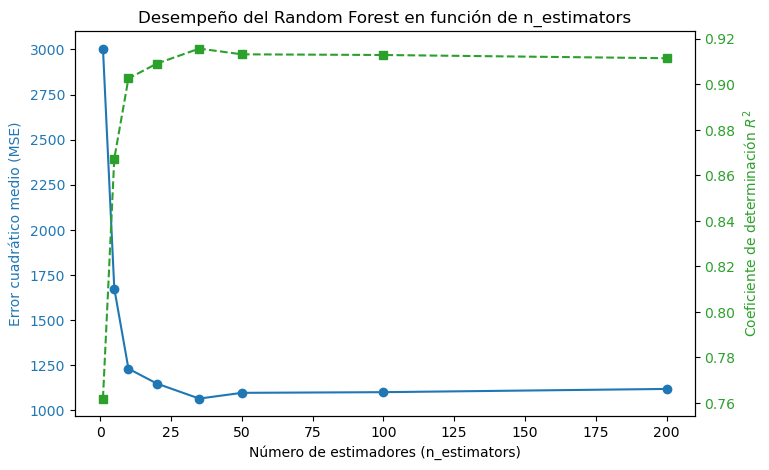

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


#=======================================================================================
#   Generar un dataset sintético de regresión
X, y = make_regression(n_samples=500, n_features=5, noise=15, random_state=42)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


#=======================================================================================
#   Rango de estimadores a probar
estimators_range = [1, 5, 10, 20, 35, 50, 100, 200]

mse_scores = []
r2_scores = []


#=======================================================================================
#   Entrenar un modelo por cada número de estimadores
for n in estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    r2_scores.append(r2)


#=======================================================================================
#   Graficar desempeño
fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel("Número de estimadores (n_estimators)")
ax1.set_ylabel("Error cuadrático medio (MSE)", color=color)
ax1.plot(estimators_range, mse_scores, marker='o', color=color, label="MSE")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Eje secundario para R^2
color = 'tab:green'
ax2.set_ylabel("Coeficiente de determinación $R^2$", color=color)
ax2.plot(estimators_range, r2_scores, marker='s', linestyle='--', color=color, label="$R^2$")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Desempeño del Random Forest en función de n_estimators")
plt.show()


### Ejemplo en *Dataset California Housing*

Este dataset contiene información real de viviendas en California (recogida por el *Census Bureau* de EE. UU.), con variables como:

- **MedInc**: Ingreso medio en el bloque.  
- **HouseAge**: Edad promedio de las casas.  
- **AveRooms**: Número promedio de habitaciones.  
- **AveBedrms**: Número promedio de dormitorios.  
- **Population**: Población del distrito.  
- **AveOccup**: Número promedio de ocupantes por hogar.  
- **Latitude** y **Longitude**: Coordenadas geográficas.  

La variable a predecir es:  

- **MedHouseVal**: Valor medio de las viviendas en la zona.  


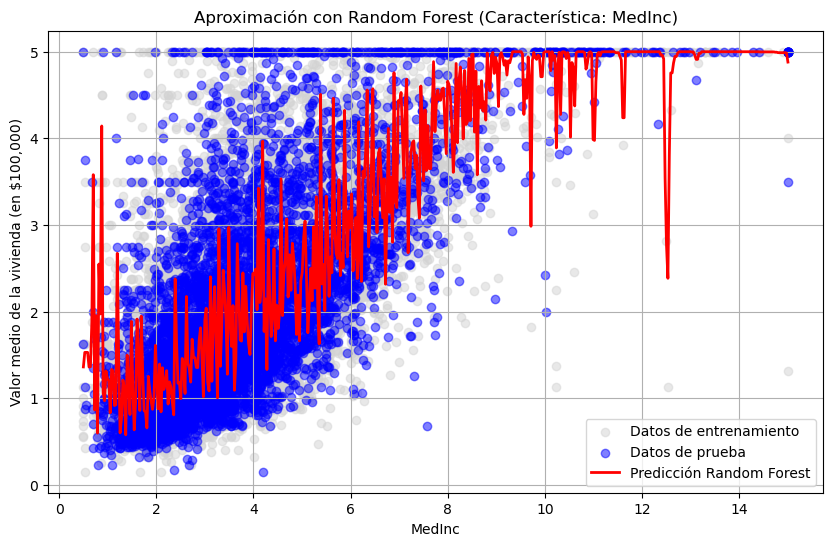

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# ===========================
# Cargar conjunto de datos
# ===========================
california = fetch_california_housing()
X, y = california.data, california.target

# Para visualización, tomamos solo una característica (ej: MedInc = índice 0)
X_feature = X[:, [0]]  # Median income
feature_name = california.feature_names[0]

# ===========================
# División entrenamiento / prueba
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X_feature, y, test_size=0.3, random_state=42
)

# ===========================
# Entrenar modelo
# ===========================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ===========================
# Visualización
# ===========================
# Crear una malla de valores de entrada para graficar predicciones
X_plot = np.linspace(X_feature.min(), X_feature.max(), 500).reshape(-1, 1)
y_pred = rf.predict(X_plot)

plt.figure(figsize=(10,6))

# Datos reales (puntos)
plt.scatter(X_train, y_train, color="lightgray", alpha=0.5, label="Datos de entrenamiento")
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Datos de prueba")

# Predicción del modelo (curva)
plt.plot(X_plot, y_pred, color="red", linewidth=2, label="Predicción Random Forest")

plt.title(f"Aproximación con Random Forest (Característica: {feature_name})")
plt.xlabel(feature_name)
plt.ylabel("Valor medio de la vivienda (en $100,000)")
plt.legend()
plt.grid(True)
plt.show()


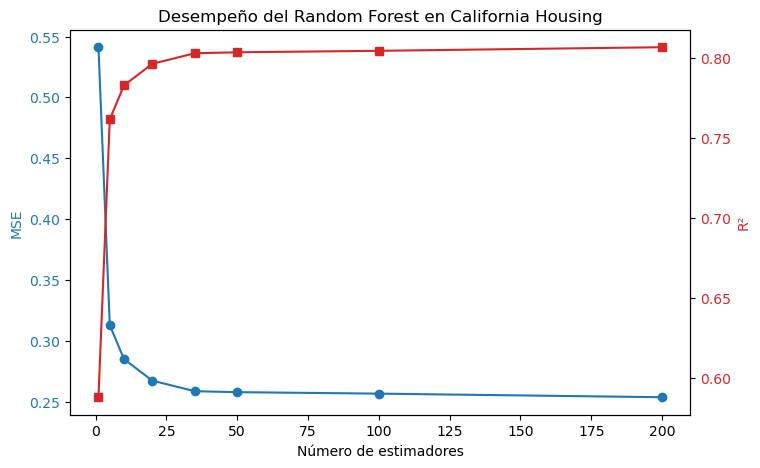

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


#=======================================================================================
#   Cargar dataset California Housing
data = fetch_california_housing()
X, y = data.data, data.target


#=======================================================================================
#   Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#=======================================================================================
#   Evaluar desempeño para distintos n_estimators
estimators_range = [1, 5, 10, 20, 35, 50, 100, 200]
mse_scores = []
r2_scores = []

for n in estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    r2_scores.append(r2)


#=======================================================================================
#   Graficar resultados
fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel("Número de estimadores")
ax1.set_ylabel("MSE", color=color)
ax1.plot(estimators_range, mse_scores, marker='o', color=color, label="MSE")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("R²", color=color)
ax2.plot(estimators_range, r2_scores, marker='s', color=color, label="R²")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Desempeño del Random Forest en California Housing")
plt.show()


## **Gradient Boosting Regressor**

La técnica **Gradient Boosting Regressor (GBR)** corresponde a un método de **ensamble secuencial**, en el cual se combinan múltiples modelos débiles (generalmente árboles de decisión de baja profundidad) para construir un modelo fuerte de regresión.  

El principio central consiste en entrenar los modelos de manera **iterativa**, de tal forma que cada nuevo estimador corrija los errores residuales del conjunto de estimadores previos.  

En cada iteración $m$, se busca aproximar la función objetivo $F(x)$ mediante un modelo aditivo:

$$
F_m(x) = F_{m-1}(x) + \nu \, h_m(x),
$$

donde:  

- $F_{m-1}(x)$ es el modelo acumulado hasta la iteración anterior.  
- $h_m(x)$ es el nuevo estimador entrenado sobre los **residuales**.  
- $\nu \in (0,1]$ es la tasa de aprendizaje (*learning rate*), que controla la contribución de cada modelo.  

El proceso puede resumirse en los siguientes pasos:  

1. Inicializar el modelo con una constante:  

$$
F_0(x) = \arg \min_\gamma \sum_{i=1}^n L(y_i, \gamma),
$$  

donde $L$ es la función de pérdida (por ejemplo, error cuadrático medio).  

2. Para cada iteración $m = 1, 2, \dots, M$:  
   - Calcular los **pseudo-residuales**:  

   $$
   r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}
   $$  

   - Entrenar un modelo $h_m(x)$ sobre los residuales $r_{im}$.  
   - Determinar el valor óptimo del coeficiente $\gamma_m$.  
   - Actualizar el modelo:  

   $$
   F_m(x) = F_{m-1}(x) + \nu \, \gamma_m h_m(x).
   $$  

En conclusión, el **Gradient Boosting Regressor** combina la idea de boosting con la optimización de gradiente, logrando un modelo potente y flexible, capaz de capturar relaciones complejas en los datos.

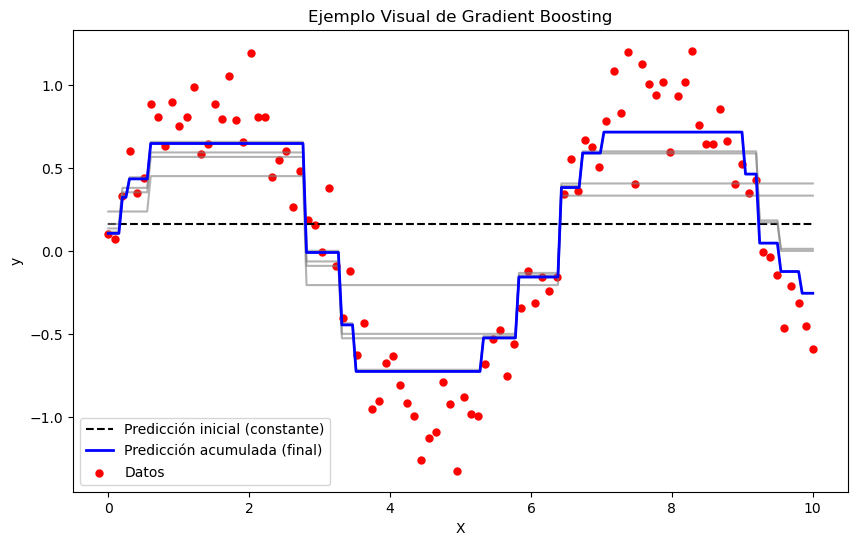

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# ---------------------------
# Generar datos sintéticos
# ---------------------------
np.random.seed(42)
X = np.linspace(0, 10, 100)[:, np.newaxis]
y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])

# ---------------------------
# Definir modelo GBM
# ---------------------------
gbm = GradientBoostingRegressor(
    n_estimators=5,      # número pequeño de iteraciones para visualizar
    learning_rate=0.5,   # peso de cada árbol débil
    max_depth=2,
    random_state=42
)

gbm.fit(X, y)

# ---------------------------
# Graficar cada iteración
# ---------------------------
xx = np.linspace(0, 10, 200)[:, np.newaxis]

plt.figure(figsize=(10, 6))

# Línea base: media inicial
init_pred = np.full_like(xx.ravel(), gbm.init_.constant_, dtype=float)
plt.plot(xx, init_pred, "--", color="black", label="Predicción inicial (constante)")

# Predicciones acumuladas
pred_acum = init_pred.copy()

# Iterar sobre los árboles débiles
for i, stage_pred in enumerate(gbm.staged_predict(xx), 1):
    plt.plot(xx, stage_pred, color="gray", alpha=0.6)  # árboles débiles (gris)
    pred_acum = stage_pred  # la predicción acumulada hasta ese punto

# Línea azul = modelo final
plt.plot(xx, pred_acum, color="blue", linewidth=2, label="Predicción acumulada (final)")

# Datos reales
plt.scatter(X, y, color="red", s=25, label="Datos")

plt.title("Ejemplo Visual de Gradient Boosting")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


### Evolución del Desempeño en GBM

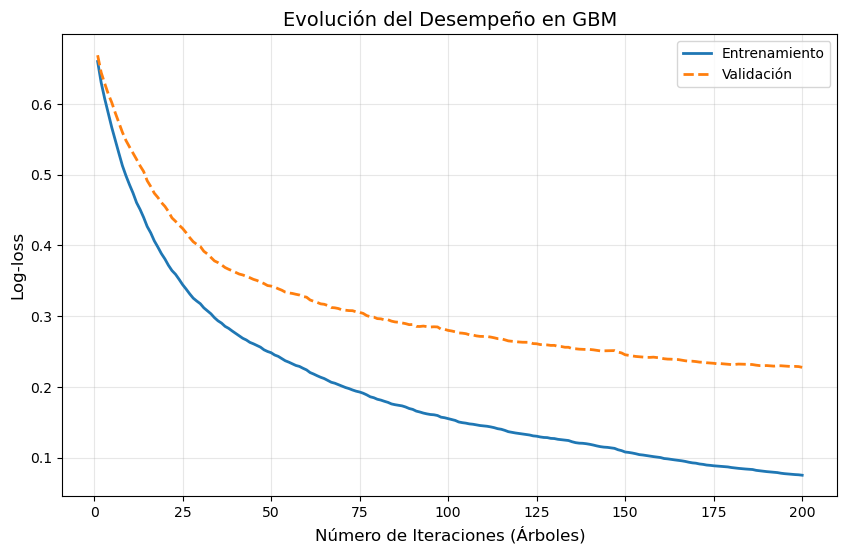

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss


#===================================================================
# Generar dataset sintético
X, y = make_classification(
    n_samples=2000, n_features=20,
    n_informative=15, n_redundant=5,
    random_state=42
)


#===================================================================
#  Dividir en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#===================================================================
#  Definir modelo Gradient Boosting
n_estimators = 200
gbm = GradientBoostingClassifier(
    n_estimators=n_estimators,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


#===================================================================
#  Entrenar el modelo
gbm.fit(X_train, y_train)

# Guardar errores de log-loss en cada iteración
train_loss = []
val_loss = []

for y_pred_train, y_pred_val in zip(
    gbm.staged_predict_proba(X_train),
    gbm.staged_predict_proba(X_val)
):
    train_loss.append(log_loss(y_train, y_pred_train))
    val_loss.append(log_loss(y_val, y_pred_val))

# Graficar evolución de iteraciones
plt.figure(figsize=(10,6))
plt.plot(range(1, n_estimators+1), train_loss, label="Entrenamiento", linewidth=2)
plt.plot(range(1, n_estimators+1), val_loss, label="Validación", linewidth=2, linestyle="--")
plt.xlabel("Número de Iteraciones (Árboles)", fontsize=12)
plt.ylabel("Log-loss", fontsize=12)
plt.title("Evolución del Desempeño en GBM", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


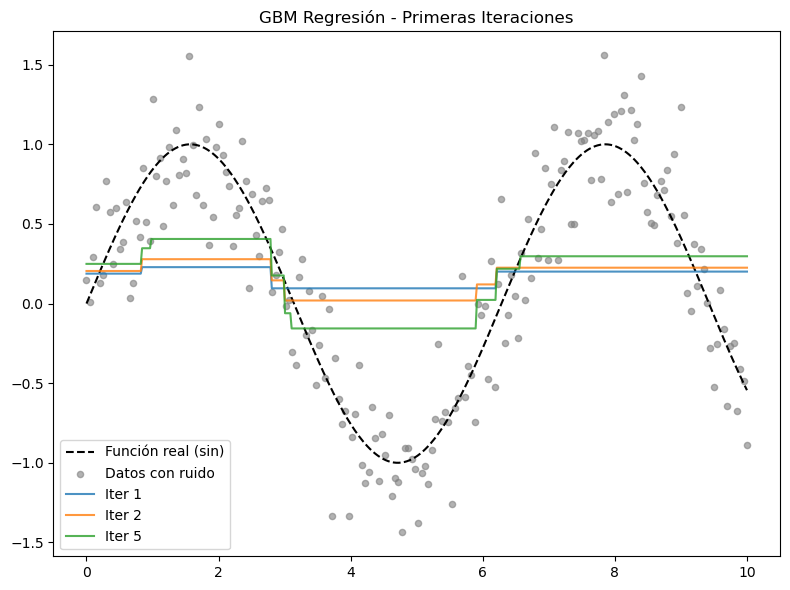

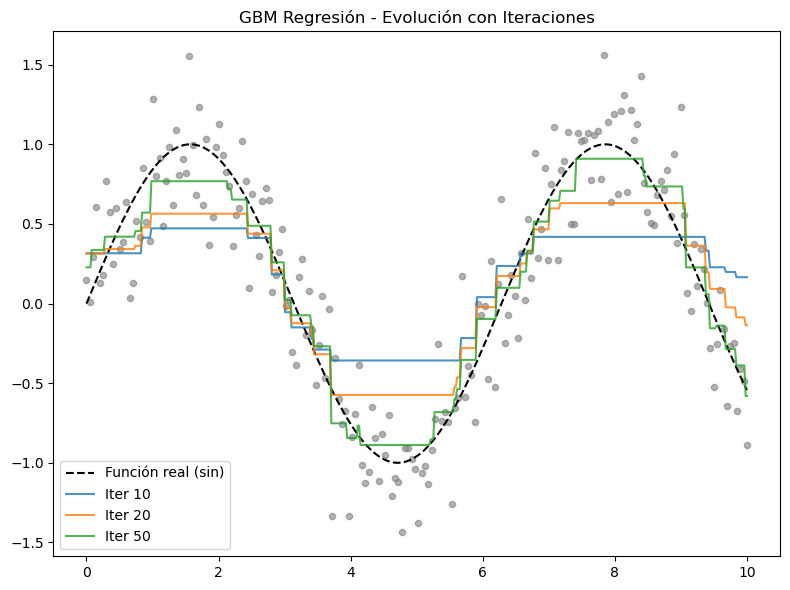

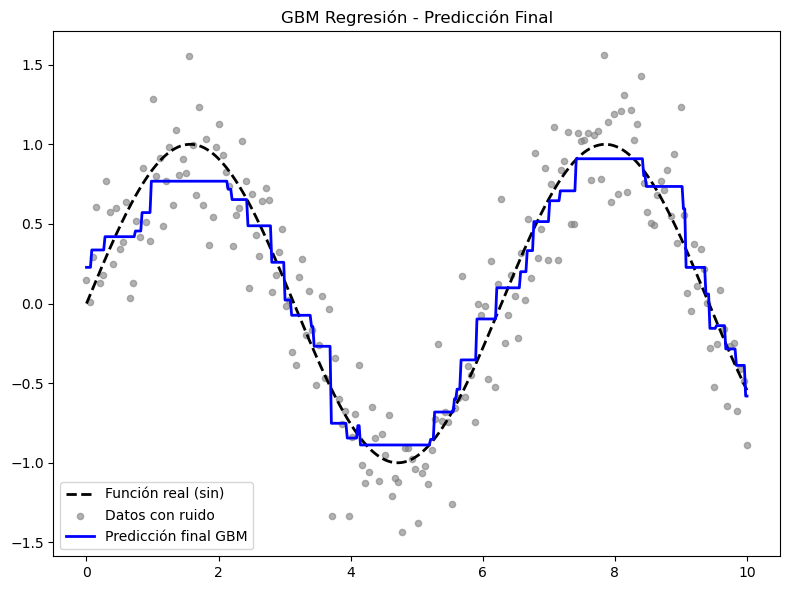

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor


#===================================================================
#  Generar datos no lineales
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y_true = np.sin(X).ravel()  # función real
y = y_true + np.random.normal(scale=0.3, size=X.shape[0])  # con ruido


#===================================================================
#  Definir modelo GBM
gbm = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1,
                                max_depth=2, random_state=42)

# Entrenamos modelo paso a paso para poder visualizar
gbm.fit(X, y)

# Espacio para predicciones
x_plot = np.linspace(0, 10, 500).reshape(-1, 1)

# --- Figura 1: primeras iteraciones ---
plt.figure(figsize=(8,6))
# Línea real
plt.plot(x_plot, np.sin(x_plot), "k--", label="Función real (sin)")
# Datos
plt.scatter(X, y, c="gray", s=20, label="Datos con ruido", alpha=0.6)

# Mostrar primeras 5 predicciones acumuladas
for i, y_pred in enumerate(gbm.staged_predict(x_plot)):
    if i in [0, 1, 4]:  # algunas iteraciones representativas
        plt.plot(x_plot, y_pred, lw=1.5, alpha=0.8, label=f"Iter {i+1}")

plt.title("GBM Regresión - Primeras Iteraciones")
plt.legend()
plt.tight_layout()
#plt.savefig("GBM_Reg.png", dpi=300)
plt.show()

# --- Figura 2: evolución con más iteraciones ---
plt.figure(figsize=(8,6))
plt.plot(x_plot, np.sin(x_plot), "k--", label="Función real (sin)")
plt.scatter(X, y, c="gray", s=20, alpha=0.6)

for i, y_pred in enumerate(gbm.staged_predict(x_plot)):
    if i in [9, 19, 49]:  # 10, 20 y 50 iteraciones
        plt.plot(x_plot, y_pred, lw=1.5, alpha=0.8, label=f"Iter {i+1}")

plt.title("GBM Regresión - Evolución con Iteraciones")
plt.legend()
plt.tight_layout()
#plt.savefig("GBM_Reg2.png", dpi=300)
plt.show()

# --- Figura 3: predicción final ---
y_pred_final = gbm.predict(x_plot)

plt.figure(figsize=(8,6))
plt.plot(x_plot, np.sin(x_plot), "k--", lw=2, label="Función real (sin)")
plt.scatter(X, y, c="gray", s=20, alpha=0.6, label="Datos con ruido")
plt.plot(x_plot, y_pred_final, "b", lw=2, label="Predicción final GBM")

plt.title("GBM Regresión - Predicción Final")
plt.legend()
plt.tight_layout()
#plt.savefig("GBM_Reg3.png", dpi=300)
plt.show()


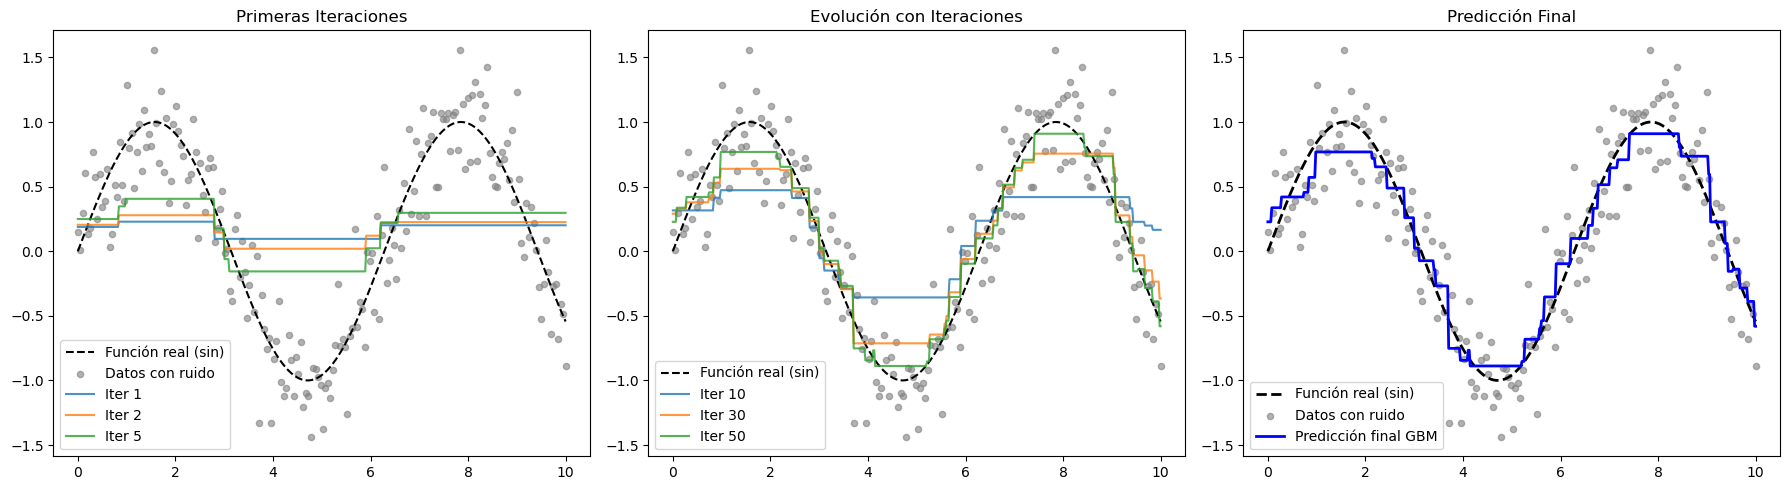

In [43]:
# --- Crear figura con 3 columnas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Figura 1: primeras iteraciones ---
axes[0].plot(x_plot, np.sin(x_plot), "k--", label="Función real (sin)")
axes[0].scatter(X, y, c="gray", s=20, alpha=0.6, label="Datos con ruido")
for i, y_pred in enumerate(gbm.staged_predict(x_plot)):
    if i in [0, 1, 4]:
        axes[0].plot(x_plot, y_pred, lw=1.5, alpha=0.8, label=f"Iter {i+1}")
axes[0].set_title("Primeras Iteraciones")
axes[0].legend()

# --- Figura 2: evolución con más iteraciones ---
axes[1].plot(x_plot, np.sin(x_plot), "k--", label="Función real (sin)")
axes[1].scatter(X, y, c="gray", s=20, alpha=0.6)
for i, y_pred in enumerate(gbm.staged_predict(x_plot)):
    if i in [9, 29, 49]:
        axes[1].plot(x_plot, y_pred, lw=1.5, alpha=0.8, label=f"Iter {i+1}")
axes[1].set_title("Evolución con Iteraciones")
axes[1].legend()

# --- Figura 3: predicción final ---
y_pred_final = gbm.predict(x_plot)
axes[2].plot(x_plot, np.sin(x_plot), "k--", lw=2, label="Función real (sin)")
axes[2].scatter(X, y, c="gray", s=20, alpha=0.6, label="Datos con ruido")
axes[2].plot(x_plot, y_pred_final, "b", lw=2, label="Predicción final GBM")
axes[2].set_title("Predicción Final")
axes[2].legend()

plt.tight_layout()
plt.show()

# FIN